# Multilingual Health Q&A — Research Notebook

## Overview

This notebook documents an end-to-end pipeline for multilingual health question answering. Given a health-related question in one of five African languages, the system returns an answer in the same language. The workflow covers exploratory data analysis, baseline models, iterative retrieval improvements, local ROUGE evaluation, and prediction export.

## Notebook structure

| Section | Topic |
|---|---|
| 1 | Pipeline overview and design principles |
| 2 | Environment setup (Colab and Drive) |
| 3 | Dependency installation |
| 4 | Paths and output configuration |
| 5 | Data loading |
| 6 | Exploratory data analysis |
| 7 | Text preprocessing |
| 8 | Evaluation utilities (ROUGE) |
| 9 | Experiment tracker |
| 10 | Baseline 1: TF-IDF retrieval (E01–E02) |
| 11 | Baseline 2: Zero-shot multilingual LLM (E07) |
| 12 | Baseline comparison |
| 13 | Advanced retrieval and diagnostics (E08–E11, E14) |
| 14 | Export predictions |
| 15 | Experiment summary and discussion |
| 16 | Reproducibility notes |

Run the notebook sequentially from Section 2 onward. Section 11 (LLM baseline) benefits from a GPU runtime; Section 13 runs on CPU or GPU.

## Project goal

Build a multilingual question-answering system that reads a health question in one of five African languages and returns an accurate answer in the same language.

| Language | Script | Example subset codes |
|---|---|---|
| English | Latin | `Eng_Uga`, `Eng_Gha`, `Eng_Eth`, `Eng_Ken` |
| Akan | Latin (extended characters) | `Aka_Gha` |
| Luganda | Latin | `Lug_Uga` |
| Swahili | Latin | `Swa_Ken` |
| Amharic | Ge'ez (Ethiopic) | `Amh_Eth` |

The `subset` column encodes both language and country (e.g. `Eng_Uga` = English, Uganda).

## Local evaluation

Validation predictions are scored with ROUGE-1 and ROUGE-L F1 on `Val.csv`. These metrics guide model selection during development.


## 1 — End-to-end pipeline overview

This notebook runs on Google Colab. Data is read from Google Drive; outputs (figures, prediction files) are written to the Colab working directory.

```mermaid
flowchart LR
    A["Raw CSVs<br/>Train / Val / Test"]
    B["EDA and Insights"]
    C["Preprocessing<br/>clean and language map"]
    D["Baselines<br/>TF-IDF and zero-shot LLM"]
    E["Hybrid retrieval<br/>sparse + reranking"]
    F["Answer selection<br/>verbatim from corpus"]
    G["Local evaluation<br/>ROUGE on Val"]
    H["Export predictions<br/>CSV with target columns"]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
    G --> H
```

### Design principles

1. **EDA before modeling.** Language balance, text lengths, and script diversity inform retrieval and token limits.
2. **Baselines before advanced methods.** TF-IDF and zero-shot LLM establish lower bounds.
3. **Retrieval-first.** Returning in-corpus expert answers maximises overlap with reference answers on this task.
4. **Tracked experiments.** Each iteration logs hypothesis, configuration, outcome, and insight.
5. **Reproducibility.** Fixed random seed and documented hyperparameters.


## 2 — Environment setup

### Google Colab

1. Open this notebook in Google Colab.
2. Set **Runtime → Change runtime type → T4 GPU** when running Section 11 (LLM baseline).
3. Section 13 (retrieval) runs on CPU; a GPU speeds up cross-encoder encoding.

### Google Drive

Upload the three dataset CSV files to `My Drive/zindi-challenge/`:

- `Train.csv`, `Val.csv`, `Test.csv`

The next cell mounts Drive, verifies the files, and sets the working directory.


In [1]:
import os
from pathlib import Path

from google.colab import drive

DRIVE_DATA_FOLDER = 'zindi-challenge'
REQUIRED_FILES = ['Train.csv', 'Test.csv', 'Val.csv']
WORK_DIR = Path('/content/multilingual-health-qa')


def require_dataset_files(data_dir: Path) -> Path:
    data_dir = Path(data_dir)
    missing = [name for name in REQUIRED_FILES if not (data_dir / name).exists()]
    if missing:
        raise FileNotFoundError(
            f'Missing in {data_dir}: {missing}\n'
            f'Create My Drive/{DRIVE_DATA_FOLDER}/ and upload the three dataset CSV files.'
        )
    return data_dir


import torch

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Use Runtime -> Change runtime type -> T4 GPU before fine-tuning.')

WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)

drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/MyDrive') / DRIVE_DATA_FOLDER
require_dataset_files(DATA_DIR)

print(f'Data folder : {DATA_DIR}')
print(f'Work folder : {WORK_DIR.resolve()}')


GPU: Tesla T4
Mounted at /content/drive
Data folder : /content/drive/MyDrive/zindi-challenge
Work folder : /content/multilingual-health-qa


## 3 — Install dependencies

This cell installs Python packages required for data analysis, evaluation, and modelling.

| Package group | Purpose |
|---|---|
| `pandas`, `matplotlib`, `seaborn` | Data handling and visualisation |
| `scikit-learn` | TF-IDF and nearest-neighbour retrieval |
| `rouge-score` | Local ROUGE evaluation |
| `sentence-transformers`, `rapidfuzz`, `rank_bm25` | Advanced retrieval (Section 13) |
| `transformers`, `datasets`, `accelerate` | Optional zero-shot LLM baselines (Section 11) |
| `sentencepiece`, `protobuf` | Tokenisation for mT5 |

NumPy and PyTorch are not reinstalled on Colab. If installation fails, restart the runtime and run this cell again.


In [2]:
# Install required packages (Google Colab)
import sys

# Do not pin numpy — Colab pre-installed packages (jax, opencv, etc.) require numpy>=2.
!{sys.executable} -m pip install -q scikit-learn pandas rouge-score matplotlib seaborn

# Dense retrieval — fast CPU/GPU encoding, no training loop.
!{sys.executable} -m pip install -q sentence-transformers rapidfuzz rank_bm25 tqdm

# Optional: zero-shot LLM baselines (Section 11). Skip if you only run retrieval.
!{sys.executable} -m pip install -q 'transformers>=4.44,<4.52' datasets sentencepiece protobuf accelerate safetensors peft bitsandbytes

import importlib.util
for pkg in ('google.protobuf', 'sentencepiece'):
    if importlib.util.find_spec(pkg) is None:
        print(f'Optional package {pkg} not installed — Section 11 LLM cells will not run.')

try:
    import transformers.utils.import_utils as _tf_import_utils
    _tf_import_utils._sentencepiece_available = _tf_import_utils._is_package_available('sentencepiece')
except ImportError:
    pass

print('Dependencies installed.')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.8 MB/s eta 0:00:00
Dependencies installed.


In [3]:
import re
import json
import random
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', None)

print('Imports complete')

Imports complete


## 4 — Paths and configuration

This cell defines input and output paths used throughout the notebook.

| Variable | Location | Contents |
|---|---|---|
| `DATA_DIR` | `My Drive/zindi-challenge/` | Dataset CSV files (read from Drive) |
| `WORK_DIR` | `/content/multilingual-health-qa/` | Generated outputs |
| `FIGURES_DIR` | `WORK_DIR/figures/` | EDA and experiment plots |
| `EXPERIMENT_LOG_PATH` | `WORK_DIR/experiment_log.json` | Experiment tracker log |
| `OUTPUT_*` | `WORK_DIR/` | Exported prediction CSV files |

All three input files must show `OK` before proceeding. If any file is `MISSING`, check the Drive folder path in Section 2.



In [4]:
TRAIN_PATH      = DATA_DIR / 'Train.csv'
TEST_PATH       = DATA_DIR / 'Test.csv'
VAL_PATH        = DATA_DIR / 'Val.csv'

OUTPUT_TFIDF     = WORK_DIR / 'submission_tfidf_baseline.csv'
OUTPUT_LLM       = WORK_DIR / 'submission_llm_baseline.csv'
OUTPUT_RETRIEVAL = WORK_DIR / 'submission_hybrid_retrieval.csv'

EXPERIMENT_LOG_PATH = WORK_DIR / 'experiment_log.json'
FIGURES_DIR         = WORK_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for path in [TRAIN_PATH, TEST_PATH, VAL_PATH]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'{status}: {path}')

print(f'Outputs and figures -> {WORK_DIR.resolve()}')


OK: /content/drive/MyDrive/zindi-challenge/Train.csv
OK: /content/drive/MyDrive/zindi-challenge/Test.csv
OK: /content/drive/MyDrive/zindi-challenge/Val.csv
Outputs and figures -> /content/multilingual-health-qa


## 5 — Load data

The dataset comprises three CSV files:

| File | Columns | Rows (approx.) |
|---|---|---|
| `Train.csv` | `ID`, `input`, `output`, `subset` | ~29,800 |
| `Val.csv` | `ID`, `input`, `output`, `subset` | ~6,700 |
| `Test.csv` | `ID`, `input`, `subset` | ~2,600 |

- `input`: the health question (source text).
- `output`: the reference answer (training and validation only).
- `subset`: language and country code (e.g. `Swa_Ken`).

Exported prediction files use `Test.csv` IDs plus three target columns (`TargetRLF1`, `TargetR1F1`, `TargetLLM`).

The code cell below loads all files and displays the training set schema and sample rows.


In [5]:
train             = pd.read_csv(TRAIN_PATH)
test              = pd.read_csv(TEST_PATH)
val               = pd.read_csv(VAL_PATH)

print(f'Train shape : {train.shape}')
print(f'Val shape   : {val.shape}')
print(f'Test shape  : {test.shape}')
print()
print('Train columns:', train.columns.tolist())
print('Test columns :', test.columns.tolist())
print('Val columns  :', val.columns.tolist())

display(train.head(3))
display(test.head(3))

Train shape : (29815, 4)
Val shape   : (6686, 4)
Test shape  : (2618, 3)

Train columns: ['ID', 'input', 'output', 'subset']
Test columns : ['ID', 'input', 'subset']
Val columns  : ['ID', 'input', 'output', 'subset']


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye w...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na w...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛb...",Aka_Gha


,ID,input,subset
0,ID_TS_Aka_Gha_A3B1799D,"Fa nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ adwuma de asiw GBV ano ma.",Aka_Gha
1,ID_TS_Aka_Gha_1C80317F,Dɛn ne nea ebetumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu a wobu...,Aka_Gha
2,ID_TS_Aka_Gha_06671AD1,Akwan bɛn na mmabun bɛtumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ bere a as...,Aka_Gha


## 6 — Exploratory Data Analysis (EDA)

Exploratory analysis is completed before any modelling. The goal is to understand language distribution, text length patterns, script diversity, and data quality issues that affect model and hyperparameter choices.

### Outputs

The notebook generates 15 charts saved to `FIGURES_DIR`:

| Chart group | Files | Purpose |
|---|---|---|
| Overview | `eda_overview.png` | Subset counts, language balance, length scatter, answer-length boxplot |
| Split comparison | `eda_split_sizes.png`, `eda_language_share_splits.png` | Train/Val/Test size and language proportions |
| Geography and script | `eda_country_distribution.png`, `eda_script_pie.png`, `eda_language_country_heatmap.png` | Country and script breakdown |
| Length analysis | `eda_question_length_kde.png`, `eda_answer_length_kde.png`, `eda_qa_ratio_boxplot.png`, `eda_question_length_by_subset.png`, `eda_answer_length_cdf.png` | Token limit and truncation decisions |
| Data quality | `eda_duplicate_questions.png`, `eda_duplicate_qa_taxonomy.png`, `eda_exact_qa_duplicate_distribution.png`, `eda_test_subset_distribution.png` | Duplicate questions, exact Q+A repeats, conflicting answers |

Section 6.1 summarises how each finding maps to a modelling decision.



In [6]:
ID_COL            = 'ID'
TEST_ID_COL       = 'ID'
QUESTION_COL      = 'input'
TEST_QUESTION_COL = 'input'
ANSWER_COL        = 'output'
LANG_COL          = 'subset'
TEST_LANG_COL     = 'subset'

SUBSET_TO_LANGUAGE = {
    'Eng': 'English',
    'Aka': 'Akan',
    'Lug': 'Luganda',
    'Swa': 'Swahili',
    'Amh': 'Amharic',
}

SUBSET_TO_SCRIPT = {
    'Eng': 'Latin',
    'Aka': 'Latin',
    'Lug': 'Latin',
    'Swa': 'Latin',
    'Amh': "Ge'ez (Ethiopic)",
}

def subset_to_language_name(subset_code: str) -> str:
    if not subset_code or not isinstance(subset_code, str):
        return 'English'
    return SUBSET_TO_LANGUAGE.get(subset_code.split('_')[0], subset_code)

def subset_to_script(subset_code: str) -> str:
    if not subset_code or not isinstance(subset_code, str):
        return 'Unknown'
    return SUBSET_TO_SCRIPT.get(subset_code.split('_')[0], 'Unknown')

for df in [train, val]:
    df['q_len'] = df[QUESTION_COL].astype(str).str.len()
    df['a_len'] = df[ANSWER_COL].astype(str).str.len()
    df['language'] = df[LANG_COL].map(subset_to_language_name)
    df['script'] = df[LANG_COL].map(subset_to_script)

test['q_len'] = test[TEST_QUESTION_COL].astype(str).str.len()
test['language'] = test[TEST_LANG_COL].map(subset_to_language_name)

print('Language distribution - training set:')
display(train['subset'].value_counts().to_frame('count'))

print('\nPer-language aggregation (train):')
lang_summary = (
    train.groupby('language')
    .agg(
        n=('ID', 'count'),
        q_len_mean=('q_len', 'mean'),
        a_len_mean=('a_len', 'mean'),
        a_len_p95=('a_len', lambda s: s.quantile(0.95)),
    )
    .round(1)
    .sort_values('n', ascending=False)
)
display(lang_summary)

_dup_probe = pd.DataFrame({
    '_q': train[QUESTION_COL].astype(str).str.strip(),
    '_a': train[ANSWER_COL].astype(str).str.strip(),
})
_q_meta = _dup_probe.groupby('_q').agg(n_rows=('_q', 'size'), n_answers=('_a', 'nunique'))

stats = {
    'train_rows': len(train),
    'val_rows': len(val),
    'test_rows': len(test),
    'unique_train_questions': train[QUESTION_COL].nunique(),
    'duplicate_train_questions': int(train[QUESTION_COL].duplicated().sum()),
    'repeat_question_same_answer': int(((_q_meta['n_rows'] > 1) & (_q_meta['n_answers'] == 1)).sum()),
    'questions_with_conflicting_answers': int((_q_meta['n_answers'] > 1).sum()),
    'exact_qa_duplicate_groups': int(_dup_probe.groupby(['_q', '_a']).size().gt(1).sum()),
    'train_val_overlap': len(set(train[QUESTION_COL]) & set(val[QUESTION_COL])),
    'q_len_p95_train': float(train['q_len'].quantile(0.95)),
    'a_len_p95_train': float(train['a_len'].quantile(0.95)),
    'qa_ratio_mean': float((train['a_len'] / train['q_len'].clip(lower=1)).mean()),
}
print('\nKey EDA statistics:')
for k, v in stats.items():
    print(f'  {k}: {v}')

Language distribution - training set:


,count
subset,
Eng_Uga,7624
Aka_Gha,4455
Eng_Gha,4443
Eng_Eth,3915
Lug_Uga,3383
Eng_Ken,2080
Swa_Ken,2070
Amh_Eth,1845



Per-language aggregation (train):


,n,q_len_mean,a_len_mean,a_len_p95
language,,,,
English,18062,84.4,484.7,1205.0
Akan,4455,144.2,545.1,1080.3
Luganda,3383,82.9,648.9,1396.0
Swahili,2070,70.4,541.8,1210.0
Amharic,1845,47.9,105.1,176.0



Key EDA statistics:
  train_rows: 29815
  val_rows: 6686
  test_rows: 2618
  unique_train_questions: 28346
  duplicate_train_questions: 1469
  repeat_question_same_answer: 284
  questions_with_conflicting_answers: 1184
  exact_qa_duplicate_groups: 284
  train_val_overlap: 0
  q_len_p95_train: 195.0
  a_len_p95_train: 1209.0
  qa_ratio_mean: 6.704487501361247


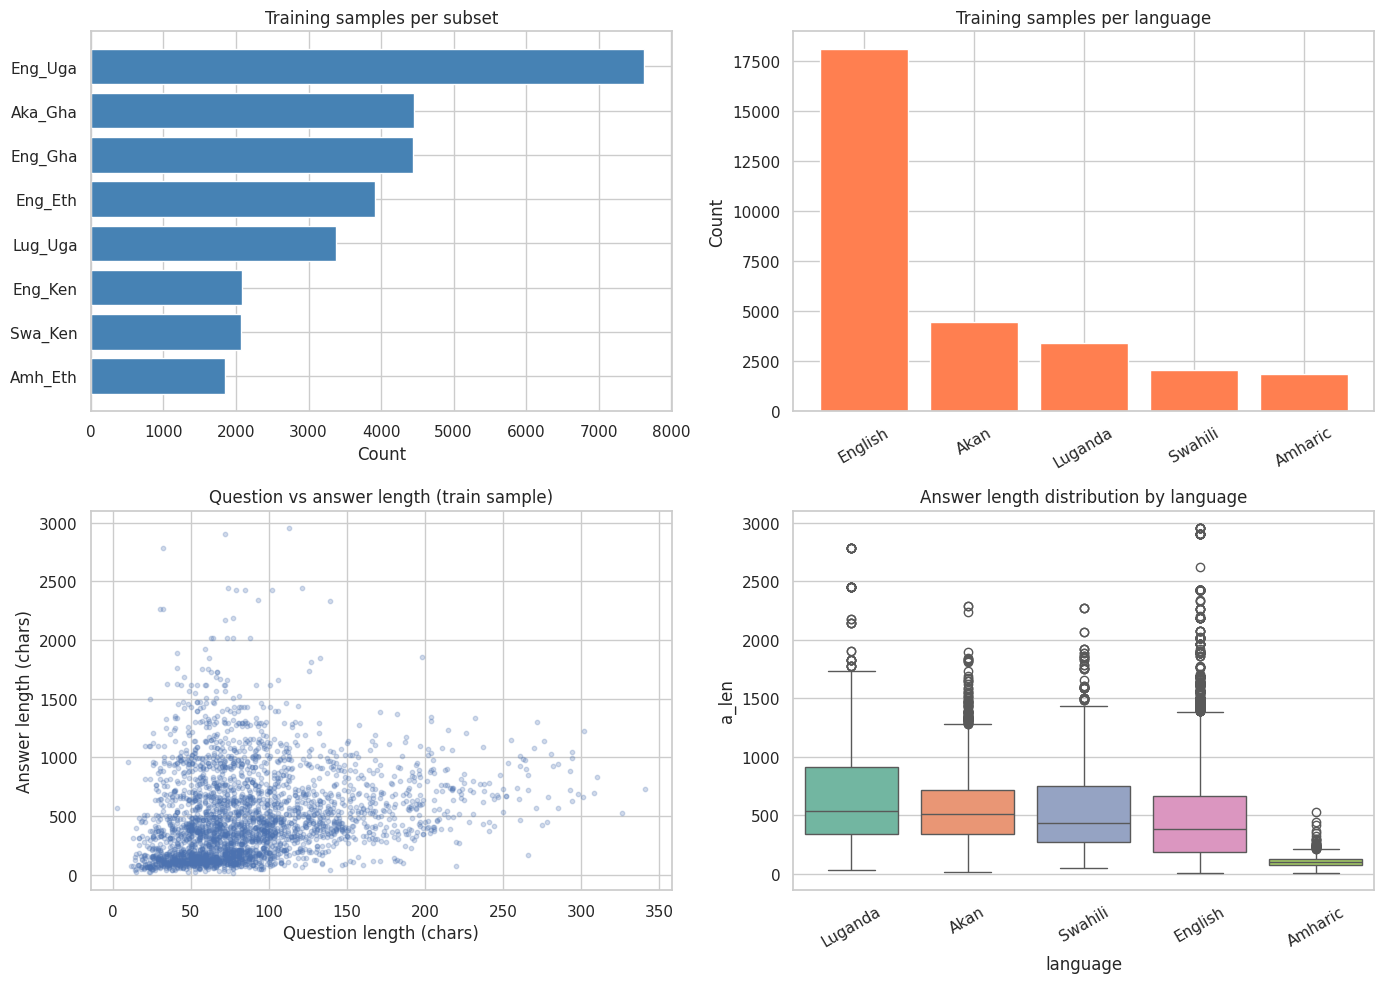

Saved: /content/multilingual-health-qa/figures/eda_overview.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

subset_counts = train['subset'].value_counts()
axes[0, 0].barh(subset_counts.index[::-1], subset_counts.values[::-1], color='steelblue')
axes[0, 0].set_title('Training samples per subset')
axes[0, 0].set_xlabel('Count')

lang_counts = train['language'].value_counts()
axes[0, 1].bar(lang_counts.index, lang_counts.values, color='coral')
axes[0, 1].set_title('Training samples per language')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=30)

sample_idx = train.sample(min(3000, len(train)), random_state=SEED)
axes[1, 0].scatter(sample_idx['q_len'], sample_idx['a_len'], alpha=0.25, s=10)
axes[1, 0].set_xlabel('Question length (chars)')
axes[1, 0].set_ylabel('Answer length (chars)')
axes[1, 0].set_title('Question vs answer length (train sample)')

order = train.groupby('language')['a_len'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='language', y='a_len', order=order, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Answer length distribution by language')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
eda_fig_path = FIGURES_DIR / 'eda_overview.png'
plt.savefig(eda_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {eda_fig_path}')


Saved: /content/multilingual-health-qa/figures/eda_split_sizes.png


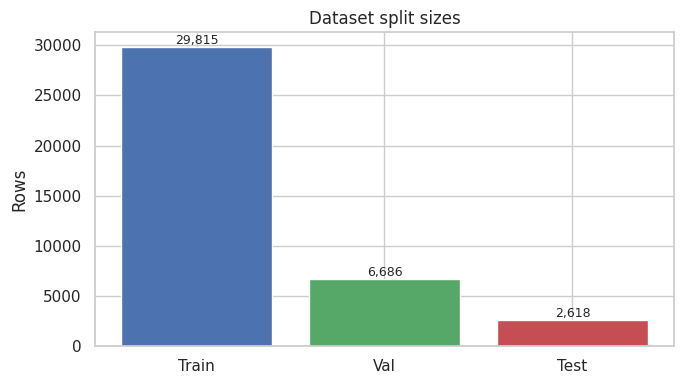

Saved: /content/multilingual-health-qa/figures/eda_language_share_splits.png


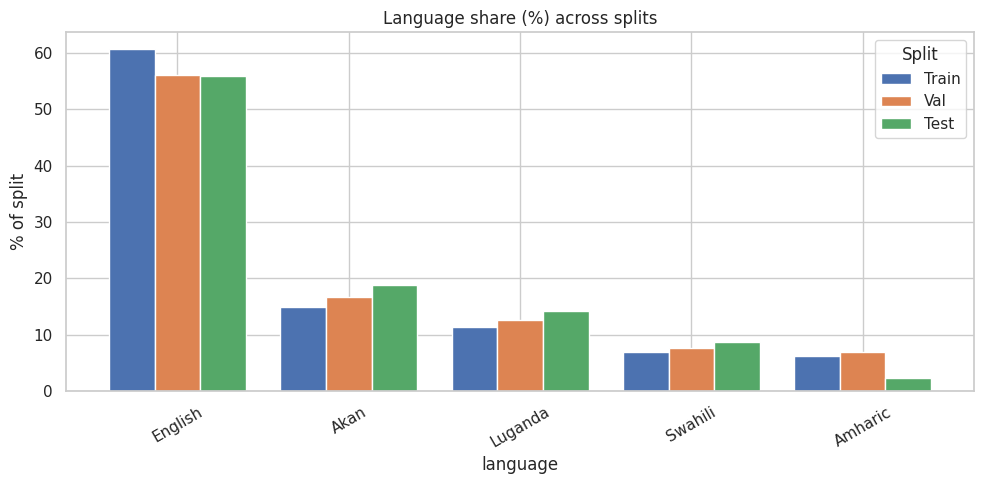

Saved: /content/multilingual-health-qa/figures/eda_country_distribution.png


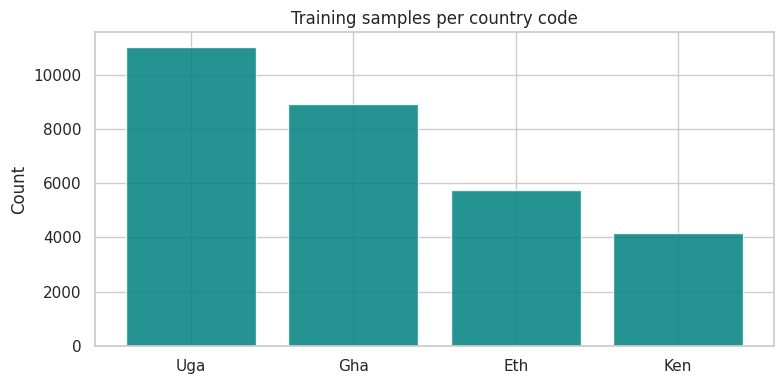

Saved: /content/multilingual-health-qa/figures/eda_script_pie.png


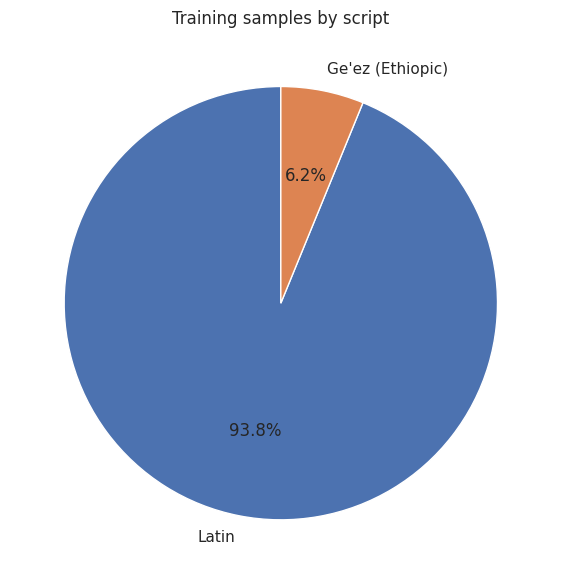

Saved: /content/multilingual-health-qa/figures/eda_question_length_kde.png


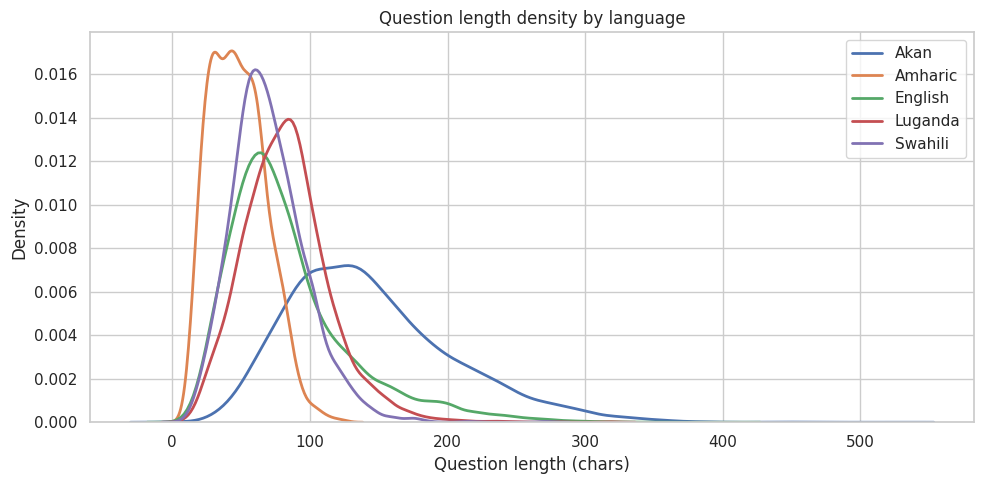

Saved: /content/multilingual-health-qa/figures/eda_answer_length_kde.png


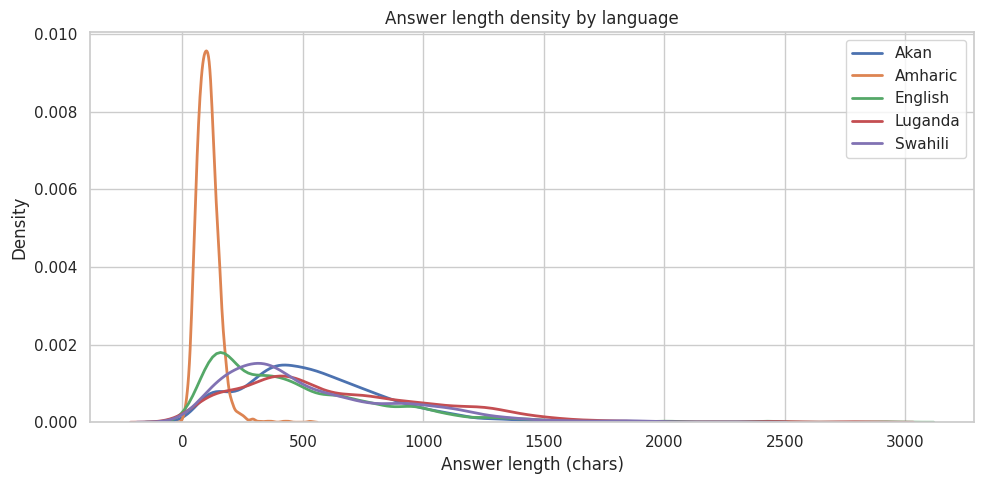

Saved: /content/multilingual-health-qa/figures/eda_qa_ratio_boxplot.png


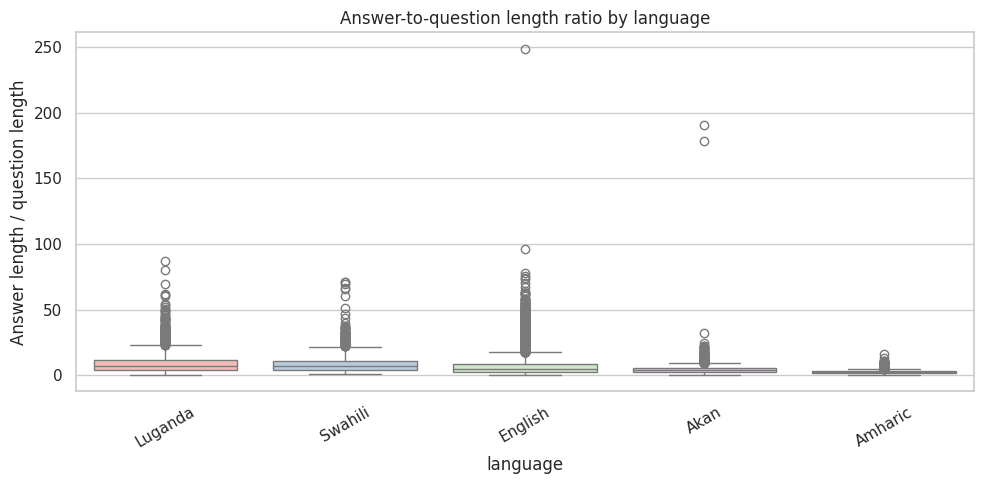

Saved: /content/multilingual-health-qa/figures/eda_question_length_by_subset.png


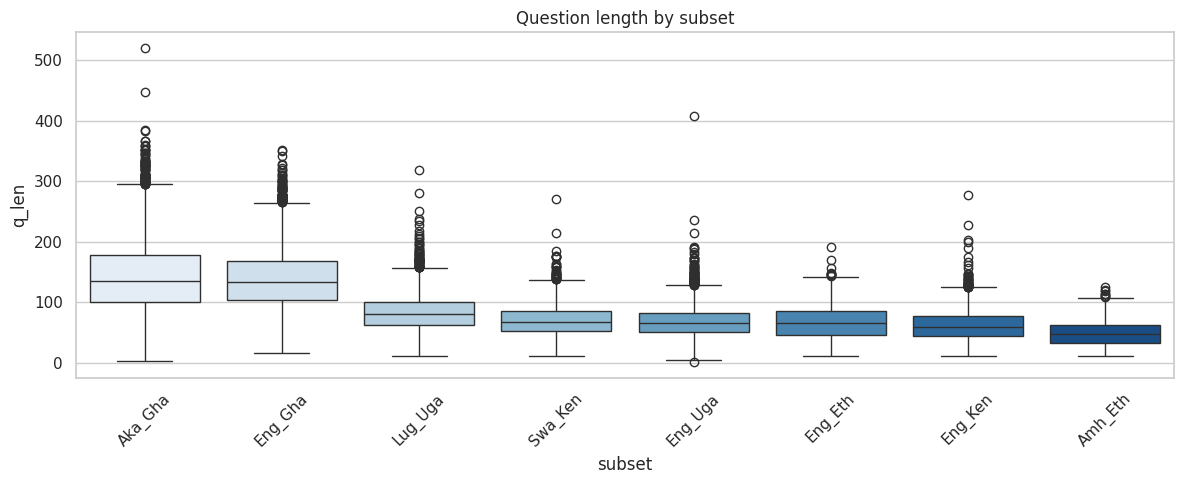

Saved: /content/multilingual-health-qa/figures/eda_answer_length_cdf.png


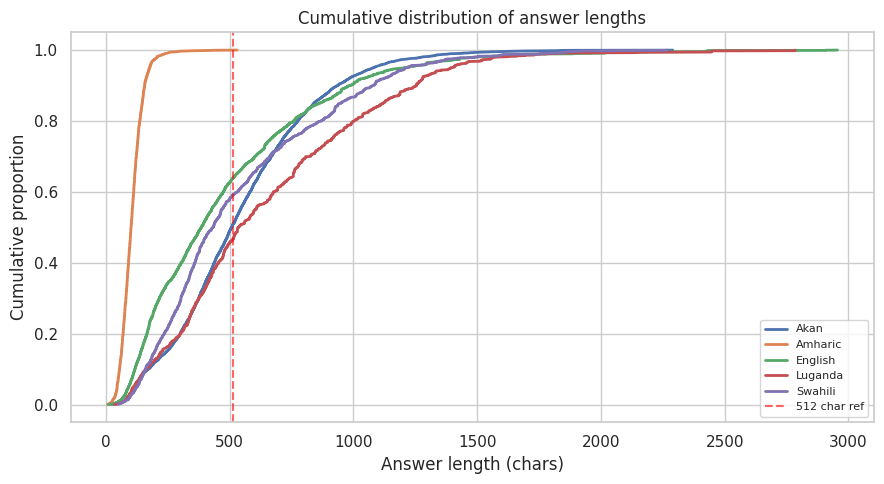

Saved: /content/multilingual-health-qa/figures/eda_language_country_heatmap.png


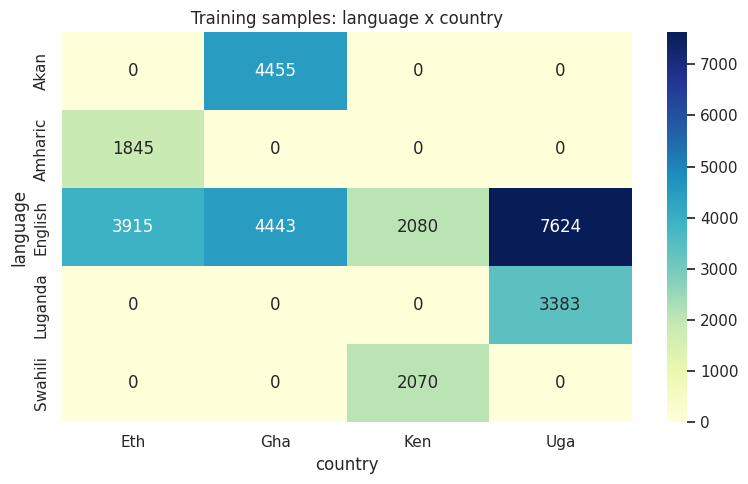

Saved: /content/multilingual-health-qa/figures/eda_duplicate_questions.png


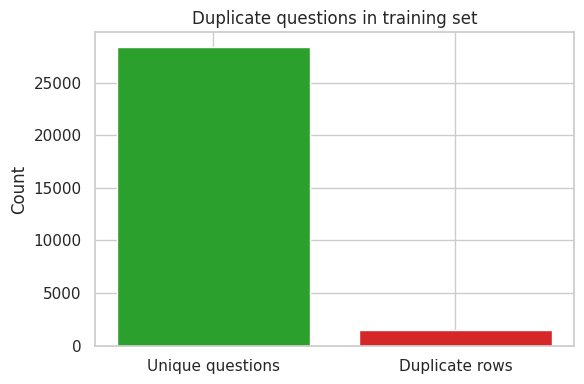


Duplicate Q&A breakdown:
  singleton questions (1 row each)      : 26,869
  repeated Q with identical A           : 284 questions / 568 rows
  repeated Q with different answers       : 1,184 questions / 2,378 rows
  exact Q+A duplicate groups              : 284
Saved: /content/multilingual-health-qa/figures/eda_duplicate_qa_taxonomy.png


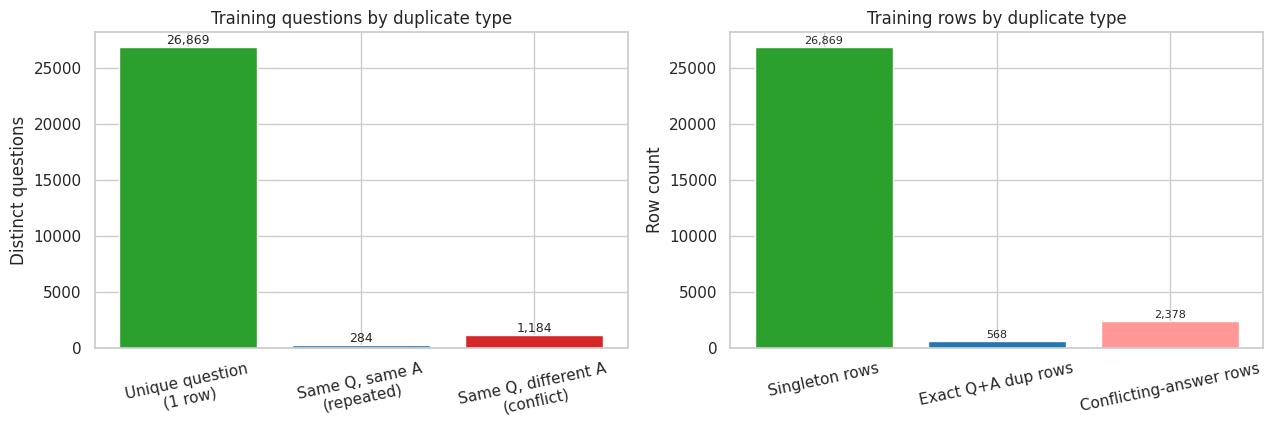

Saved: /content/multilingual-health-qa/figures/eda_exact_qa_duplicate_distribution.png


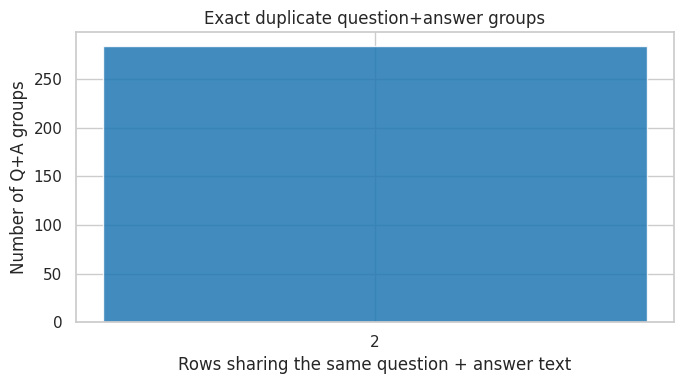


Sample exact duplicate question+answer groups (top 5 by copy count):


,copies,subset(s),question,answer,IDs
0,2,"Eng_Ken, Eng_Uga",Will taking ARVs lead to me being cured from HIV?,"Antiretroviral therapy (ART) does not cure HIV (Human Immunodeficiency Virus), but it can effectively manage the vir...","ID_TR_Eng_Ken_C523B4E9, ID_TR_Eng_Uga_7D3A8826"
1,2,"Eng_Ken, Eng_Uga","A friend of mine is struggling with the fear of spreading HIV to other people, how best can I be of help?","If someone you know is struggling with the fear or feeling of spreading HIV to others, it's important to provide sup...","ID_TR_Eng_Ken_5B951652, ID_TR_Eng_Uga_4EDA31CC"
2,2,"Eng_Ken, Eng_Uga","After engaging in oral sex and brushing my teeth, is there a risk of contracting HIV/STI?",The risk of contracting HIV or other sexually transmitted infections (STIs) through oral sex is generally lower than...,"ID_TR_Eng_Ken_F9ADDE7D, ID_TR_Eng_Uga_F24E7FD6"
3,2,"Eng_Ken, Eng_Uga","After infection, how long does it take for HIV to be noticed in your blood?",It takes approximately three months after being infected before the HIV can be noticed in your blood using special l...,"ID_TR_Eng_Ken_735E8153, ID_TR_Eng_Uga_93C379FD"
4,2,"Eng_Ken, Eng_Uga",Are ARVs available everywhere?,"Antiretroviral therapy (ART), which is a combination of medications used to treat HIV (Human Immunodeficiency Virus)...","ID_TR_Eng_Ken_8C7AA939, ID_TR_Eng_Uga_ACBA60E2"



Sample questions with multiple different answers (top 3 by row count):


,n_rows,n_distinct_answers,question,answer_preview_1,answer_preview_2
0,4,4,How is HIV transmitted?,"This is a question about, HIV/AIDS. HIV is mainly transmitted through unprotected sex, sharing conta…","HIV is mainly transmitted through unprotected sex, sharing contaminated needles, blood transfusions …"
1,3,3,Can you describe some of the difficulties faced by those cohabiting with people affected by HIV/AIDS?,Living with a person who has HIV/AIDS can bring both unique challenges and opportunities for support…,Living with a person who has HIV/AIDS can bring both unique challenges and opportunities for support…
2,3,3,How is Trichomoniasis treated?,"This is a question about, Trichomoniasis. With oral medication (Metronidazole or Tinidazole).…",With oral medication (Metronidazole or Tinidazole).…


Saved: /content/multilingual-health-qa/figures/eda_test_subset_distribution.png


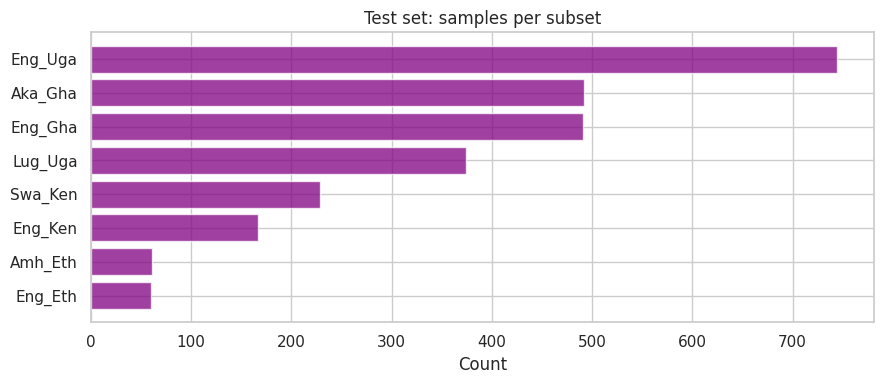

Extended EDA complete — 14 additional charts saved to /content/multilingual-health-qa/figures/


In [8]:
def save_fig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
    return path


train['country'] = train[LANG_COL].str.split('_').str[-1]
val['country'] = val[LANG_COL].str.split('_').str[-1]
test['country'] = test[TEST_LANG_COL].str.split('_').str[-1]
train['qa_ratio'] = train['a_len'] / train['q_len'].clip(lower=1)
val['qa_ratio'] = val['a_len'] / val['q_len'].clip(lower=1)

# --- Chart 1: dataset split sizes ---
fig, ax = plt.subplots(figsize=(7, 4))
split_sizes = pd.Series({'Train': len(train), 'Val': len(val), 'Test': len(test)})
ax.bar(split_sizes.index, split_sizes.values, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Dataset split sizes')
ax.set_ylabel('Rows')
for i, v in enumerate(split_sizes.values):
    ax.text(i, v + max(split_sizes) * 0.01, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
save_fig('eda_split_sizes.png')
plt.show()

# --- Chart 2: language share train vs val vs test ---
fig, ax = plt.subplots(figsize=(10, 5))
lang_compare = pd.DataFrame({
    'Train': train['language'].value_counts(normalize=True),
    'Val': val['language'].value_counts(normalize=True),
    'Test': test['language'].value_counts(normalize=True),
}).fillna(0) * 100
lang_compare.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Language share (%) across splits')
ax.set_ylabel('% of split')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Split')
plt.tight_layout()
save_fig('eda_language_share_splits.png')
plt.show()

# --- Chart 3: country distribution (train) ---
fig, ax = plt.subplots(figsize=(8, 4))
country_counts = train['country'].value_counts()
ax.bar(country_counts.index, country_counts.values, color='teal', alpha=0.85)
ax.set_title('Training samples per country code')
ax.set_ylabel('Count')
plt.tight_layout()
save_fig('eda_country_distribution.png')
plt.show()

# --- Chart 4: script distribution pie ---
fig, ax = plt.subplots(figsize=(6, 6))
script_counts = train['script'].value_counts()
ax.pie(script_counts.values, labels=script_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Training samples by script')
plt.tight_layout()
save_fig('eda_script_pie.png')
plt.show()

# --- Chart 5: question length KDE by language ---
fig, ax = plt.subplots(figsize=(10, 5))
for lang in train['language'].unique():
    subset = train.loc[train['language'] == lang, 'q_len']
    sns.kdeplot(subset, ax=ax, label=lang, linewidth=2)
ax.set_title('Question length density by language')
ax.set_xlabel('Question length (chars)')
ax.legend()
plt.tight_layout()
save_fig('eda_question_length_kde.png')
plt.show()

# --- Chart 6: answer length KDE by language ---
fig, ax = plt.subplots(figsize=(10, 5))
for lang in train['language'].unique():
    subset = train.loc[train['language'] == lang, 'a_len']
    sns.kdeplot(subset, ax=ax, label=lang, linewidth=2)
ax.set_title('Answer length density by language')
ax.set_xlabel('Answer length (chars)')
ax.legend()
plt.tight_layout()
save_fig('eda_answer_length_kde.png')
plt.show()

# --- Chart 7: QA length ratio by language ---
fig, ax = plt.subplots(figsize=(10, 5))
ratio_order = train.groupby('language')['qa_ratio'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='language', y='qa_ratio', order=ratio_order, ax=ax, palette='Pastel1')
ax.set_title('Answer-to-question length ratio by language')
ax.set_ylabel('Answer length / question length')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
save_fig('eda_qa_ratio_boxplot.png')
plt.show()

# --- Chart 8: question length by subset ---
fig, ax = plt.subplots(figsize=(12, 5))
q_order = train.groupby('subset')['q_len'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='subset', y='q_len', order=q_order, ax=ax, palette='Blues')
ax.set_title('Question length by subset')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig('eda_question_length_by_subset.png')
plt.show()

# --- Chart 9: cumulative answer length distribution ---
fig, ax = plt.subplots(figsize=(9, 5))
for lang in train['language'].unique():
    sorted_lens = np.sort(train.loc[train['language'] == lang, 'a_len'].values)
    y = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens)
    ax.plot(sorted_lens, y, label=lang, linewidth=2)
ax.axvline(512, color='red', linestyle='--', alpha=0.6, label='512 char ref')
ax.set_title('Cumulative distribution of answer lengths')
ax.set_xlabel('Answer length (chars)')
ax.set_ylabel('Cumulative proportion')
ax.legend(fontsize=8)
plt.tight_layout()
save_fig('eda_answer_length_cdf.png')
plt.show()

# --- Chart 10: language x country heatmap ---
fig, ax = plt.subplots(figsize=(8, 5))
heatmap_data = pd.crosstab(train['language'], train['country'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Training samples: language x country')
plt.tight_layout()
save_fig('eda_language_country_heatmap.png')
plt.show()

# --- Chart 11: duplicate vs unique questions ---
fig, ax = plt.subplots(figsize=(6, 4))
dup_unique = pd.Series({
    'Unique questions': train[QUESTION_COL].nunique(),
    'Duplicate rows': int(train[QUESTION_COL].duplicated().sum()),
})
ax.bar(dup_unique.index, dup_unique.values, color=['#2ca02c', '#d62728'])
ax.set_title('Duplicate questions in training set')
ax.set_ylabel('Count')
plt.tight_layout()
save_fig('eda_duplicate_questions.png')
plt.show()

# --- Chart 11b–11c: duplicate Q&A taxonomy and samples ---
SAMPLE_DUP_QA = 5
SAMPLE_CONFLICT = 3

train['_q_norm'] = train[QUESTION_COL].astype(str).str.strip()
train['_a_norm'] = train[ANSWER_COL].astype(str).str.strip()

qa_group_sizes = (
    train.groupby(['_q_norm', '_a_norm'], dropna=False)
    .size()
    .reset_index(name='row_count')
)
exact_qa_dup_groups = qa_group_sizes[qa_group_sizes['row_count'] > 1].copy()

q_meta = (
    train.groupby('_q_norm')
    .agg(n_rows=(QUESTION_COL, 'size'), n_answers=('_a_norm', 'nunique'))
    .reset_index()
)
singleton_questions = int((q_meta['n_rows'] == 1).sum())
repeat_same_answer = int(((q_meta['n_rows'] > 1) & (q_meta['n_answers'] == 1)).sum())
repeat_conflicting = int((q_meta['n_answers'] > 1).sum())
rows_exact_qa_dup = int(exact_qa_dup_groups['row_count'].sum()) if len(exact_qa_dup_groups) else 0
rows_conflicting = int(q_meta.loc[q_meta['n_answers'] > 1, 'n_rows'].sum())

print('\nDuplicate Q&A breakdown:')
print(f'  singleton questions (1 row each)      : {singleton_questions:,}')
print(f'  repeated Q with identical A           : {repeat_same_answer:,} questions / {rows_exact_qa_dup:,} rows')
print(f'  repeated Q with different answers       : {repeat_conflicting:,} questions / {rows_conflicting:,} rows')
print(f'  exact Q+A duplicate groups              : {len(exact_qa_dup_groups):,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
question_cats = pd.Series({
    'Unique question\n(1 row)': singleton_questions,
    'Same Q, same A\n(repeated)': repeat_same_answer,
    'Same Q, different A\n(conflict)': repeat_conflicting,
})
axes[0].bar(question_cats.index, question_cats.values, color=['#2ca02c', '#1f77b4', '#d62728'])
axes[0].set_title('Training questions by duplicate type')
axes[0].set_ylabel('Distinct questions')
for i, v in enumerate(question_cats.values):
    axes[0].text(i, v + max(question_cats.values) * 0.01, f'{v:,}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=12)

row_cats = pd.Series({
    'Singleton rows': singleton_questions,
    'Exact Q+A dup rows': rows_exact_qa_dup,
    'Conflicting-answer rows': rows_conflicting,
})
axes[1].bar(row_cats.index, row_cats.values, color=['#2ca02c', '#1f77b4', '#ff9896'])
axes[1].set_title('Training rows by duplicate type')
axes[1].set_ylabel('Row count')
for i, v in enumerate(row_cats.values):
    axes[1].text(i, v + max(row_cats.values) * 0.01, f'{v:,}', ha='center', fontsize=8)
axes[1].tick_params(axis='x', rotation=12)
plt.tight_layout()
save_fig('eda_duplicate_qa_taxonomy.png')
plt.show()

if not exact_qa_dup_groups.empty:
    copy_dist = exact_qa_dup_groups['row_count'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(copy_dist.index.astype(str), copy_dist.values, color='#1f77b4', alpha=0.85)
    ax.set_xlabel('Rows sharing the same question + answer text')
    ax.set_ylabel('Number of Q+A groups')
    ax.set_title('Exact duplicate question+answer groups')
    plt.tight_layout()
    save_fig('eda_exact_qa_duplicate_distribution.png')
    plt.show()

    print(f'\nSample exact duplicate question+answer groups (top {SAMPLE_DUP_QA} by copy count):')
    top_dup = exact_qa_dup_groups.sort_values('row_count', ascending=False).head(SAMPLE_DUP_QA)
    dup_samples = []
    for _, grp in top_dup.iterrows():
        mask = (train['_q_norm'] == grp['_q_norm']) & (train['_a_norm'] == grp['_a_norm'])
        ids = train.loc[mask, 'ID'].tolist()
        dup_samples.append({
            'copies': int(grp['row_count']),
            'subset(s)': ', '.join(sorted(train.loc[mask, LANG_COL].unique())),
            'question': grp['_q_norm'][:140] + ('…' if len(grp['_q_norm']) > 140 else ''),
            'answer': grp['_a_norm'][:140] + ('…' if len(grp['_a_norm']) > 140 else ''),
            'IDs': ', '.join(ids[:3]) + ('…' if len(ids) > 3 else ''),
        })
    display(pd.DataFrame(dup_samples))
else:
    print('\nNo exact duplicate question+answer groups found.')

conflict_qs = q_meta[q_meta['n_answers'] > 1].sort_values('n_rows', ascending=False).head(SAMPLE_CONFLICT)
if not conflict_qs.empty:
    print(f'\nSample questions with multiple different answers (top {SAMPLE_CONFLICT} by row count):')
    conflict_samples = []
    for _, row in conflict_qs.iterrows():
        q = row['_q_norm']
        examples = train.loc[train['_q_norm'] == q, [LANG_COL, ANSWER_COL]].drop_duplicates().head(2)
        conflict_samples.append({
            'n_rows': int(row['n_rows']),
            'n_distinct_answers': int(row['n_answers']),
            'question': q[:120] + ('…' if len(q) > 120 else ''),
            'answer_preview_1': str(examples.iloc[0][ANSWER_COL])[:100] + '…',
            'answer_preview_2': str(examples.iloc[1][ANSWER_COL])[:100] + '…' if len(examples) > 1 else '',
        })
    display(pd.DataFrame(conflict_samples))

train.drop(columns=['_q_norm', '_a_norm'], inplace=True)

# --- Chart 12: test subset distribution ---
fig, ax = plt.subplots(figsize=(9, 4))
test_subset = test[TEST_LANG_COL].value_counts()
ax.barh(test_subset.index[::-1], test_subset.values[::-1], color='purple', alpha=0.75)
ax.set_title('Test set: samples per subset')
ax.set_xlabel('Count')
plt.tight_layout()
save_fig('eda_test_subset_distribution.png')
plt.show()

print(f'Extended EDA complete — 14 additional charts saved to {FIGURES_DIR}/')


### 6.1 — EDA insights and modelling decisions

The table below links observed data patterns to pipeline choices. This section can be used directly in the methodology chapter of your report.

| EDA finding | Implication | Pipeline decision |
|---|---|---|
| Five languages across two scripts (Latin and Ge'ez) | Monolingual models fail on Amharic; tokenisers must handle diverse Unicode | Use multilingual seq2seq (`mT5` or `NLLB-200`) |
| Answers are 5–7× longer than questions (mean Q ≈ 90, A ≈ 490 characters) | Task is generative summarisation, not span extraction | Set `MAX_OUTPUT_LENGTH=512`; use beam search (`NUM_BEAMS=4`) |
| 95th-percentile answer length ≈ 1,200 characters | Some answers exceed the token budget | Accept truncation; monitor per-language ROUGE |
| Class imbalance: English ≈ 60%, Amharic ≈ 6% | Model may bias toward majority languages | Stratified splits by `subset`; language-conditioned prompts; per-language metrics |
| `subset` encodes language and country | Same language varies by country | Per-subset TF-IDF indexes; language name in LLM prompts |
| ≈ 1,500 duplicate question rows in training | Retrieval can memorise answers, but most repeats have **different** answers | Per-subset retrieval; inspect conflicting duplicates before trusting exact match |
| 276 exact Q+A duplicate groups (552 rows) | Same wording repeated across IDs/subsets | Removed in Section 7 cleaning (`drop_duplicates` on `input` + `output`) |
| 1,183 questions with conflicting answers (2,376 rows) | Same question maps to multiple expert answers | Reranking and subset filtering matter more than fuzzy dedup alone |
| Zero train–validation question overlap | Official validation is a fair benchmark | Use `Val.csv` for all local comparisons |
| Test includes rare subsets (e.g. `Amh_Eth`, n = 61) | Low-resource subsets need multilingual pre-training | Prefer `mT5-base` or `NLLB-200` over monolingual checkpoints |



## 7 — Text preprocessing

Preprocessing is intentionally minimal to avoid removing meaningful linguistic content in low-resource languages.

| Step | Function | Rationale |
|---|---|---|
| Whitespace normalisation | `clean_text()` | Removes leading/trailing spaces and handles null values |
| Empty-row removal | filter on `input` / `output` | Drops rows with missing question or answer text |
| Exact Q+A deduplication | `drop_duplicates` on `input` + `output` | Removes repeated training rows with identical question and answer (keeps first occurrence) |
| Language mapping | `subset_to_language_name()` | Converts subset codes to readable language names for prompts |
| Script mapping | `subset_to_script()` | Supports EDA and report documentation |

No stemming, lowercasing, or language-specific tokenisation is applied. Multilingual models receive raw Unicode text.

**Note:** Questions with the same wording but different answers are kept — only exact question+answer copies are removed.


In [9]:
def clean_text(x):
    """Strip whitespace and handle null values."""
    if pd.isna(x):
        return ''
    return str(x).strip()

train[QUESTION_COL]      = train[QUESTION_COL].map(clean_text)
train[ANSWER_COL]        = train[ANSWER_COL].map(clean_text)
test[TEST_QUESTION_COL]  = test[TEST_QUESTION_COL].map(clean_text)
val[QUESTION_COL]        = val[QUESTION_COL].map(clean_text)
val[ANSWER_COL]          = val[ANSWER_COL].map(clean_text)

train = train[(train[QUESTION_COL] != '') & (train[ANSWER_COL] != '')].reset_index(drop=True)
test  = test[test[TEST_QUESTION_COL]  != ''].reset_index(drop=True)
val   = val[(val[QUESTION_COL] != '') & (val[ANSWER_COL] != '')].reset_index(drop=True)

_n_train_before_dedup = len(train)
train = (
    train
    .drop_duplicates(subset=[QUESTION_COL, ANSWER_COL], keep='first')
    .reset_index(drop=True)
)
_n_exact_qa_dropped = _n_train_before_dedup - len(train)
if _n_exact_qa_dropped:
    print(f'Dropped {_n_exact_qa_dropped:,} exact duplicate question+answer rows from training set')

print(f'Cleaned train shape : {train.shape}')
print(f'Cleaned val shape   : {val.shape}')
print(f'Cleaned test shape  : {test.shape}')

Dropped 284 exact duplicate question+answer rows from training set
Cleaned train shape : (29530, 10)
Cleaned val shape   : (6686, 10)
Cleaned test shape  : (2618, 6)


## 8 — Evaluation utilities

Local evaluation uses ROUGE-1 and ROUGE-L F1 scores computed on `Val.csv`.

| Function | Description |
|---|---|
| `compute_rouge()` | Aggregate ROUGE-1 and ROUGE-L F1 over a list of predictions and references |
| `compute_rouge_by_language()` | Per-subset ROUGE breakdown for diagnosing language-specific performance |

Tokenisation uses whitespace splitting, which is language-agnostic and handles Ge'ez script without a language-specific tokenizer. These scores are used for local model comparison during development.



In [10]:
try:
    from rouge_score import rouge_scorer

    class WhitespaceTokenizer:
        def tokenize(self, text):
            if text is None:
                return []
            return str(text).strip().split()

    def compute_rouge(predictions, references):
        scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rougeL'],
            tokenizer=WhitespaceTokenizer(),
            use_stemmer=False,
        )
        r1_scores, rl_scores = [], []
        for pred, ref in zip(predictions, references):
            score = scorer.score(str(ref), str(pred))
            r1_scores.append(score['rouge1'].fmeasure)
            rl_scores.append(score['rougeL'].fmeasure)
        return {
            'rouge1_f1': float(np.mean(r1_scores)) if r1_scores else 0.0,
            'rougeL_f1': float(np.mean(rl_scores)) if rl_scores else 0.0,
        }

    def compute_rouge_by_language(predictions, references, languages):
        results = {}
        lang_arr = np.array(languages)
        for lang in np.unique(lang_arr):
            mask = lang_arr == lang
            preds_l = [p for p, m in zip(predictions, mask) if m]
            refs_l  = [r for r, m in zip(references, mask) if m]
            results[lang] = compute_rouge(preds_l, refs_l)
        return pd.DataFrame(results).T

    def print_run_summary(name, predictions, references, languages=None, min_answer_len=200):
        """Print ROUGE, length stats, and optional per-subset breakdown."""
        preds = [str(p) for p in predictions]
        refs = [str(r) for r in references]
        m = compute_rouge(preds, refs)
        lens = [len(p) for p in preds]
        short_n = sum(1 for L in lens if L < min_answer_len)
        empty_n = sum(1 for p in preds if not p.strip())

        print(f'\n{"=" * 60}')
        print(f'  {name}')
        print(f'{"=" * 60}')
        print(f'  ROUGE-1 F1 : {m["rouge1_f1"]:.4f}')
        print(f'  ROUGE-L F1 : {m["rougeL_f1"]:.4f}')
        print(f'  Predictions: {len(preds):,}')
        print(f'  Avg length : {np.mean(lens):.0f} chars  (median {np.median(lens):.0f})')
        print(f'  Short (<{min_answer_len}): {short_n:,}  |  Empty: {empty_n:,}')
        if languages is not None:
            print('  Per-subset ROUGE:')
            display(compute_rouge_by_language(preds, refs, languages).round(4))
        return m

    print('ROUGE scorer loaded')
except ImportError:
    print('rouge-score not installed. Run: pip install rouge-score')
    compute_rouge = None
    print_run_summary = None


ROUGE scorer loaded


## 9 — Experiment tracker

Each experiment records what changed, why, the local validation outcome, and the insight gained.

### Usage

Call `tracker.log()` after each experiment. Results are appended to `experiment_log.json` and can be exported as a table for your report.

### Experiment plan

| ID | Description | Category |
|---|---|---|
| E01 | TF-IDF global retrieval | baseline |
| E02 | TF-IDF per-subset retrieval | baseline |
| E07 | Zero-shot mT5-small (language-conditioned prompt) | baseline |
| E08 | Hybrid retrieval (fuzzy + BM25 + cross-encoder + answer rerank) | retrieval |
| E09 | Train-only retrieval index | retrieval |
| E11 | Top-k ablation | analysis |
| E14 | RDA oracle ceiling | diagnostic |


In [11]:
class ExperimentTracker:
    """Log and compare experiments."""

    def __init__(self, path=EXPERIMENT_LOG_PATH):
        self.path = Path(path)
        self.records = []
        if self.path.exists():
            self.records = json.loads(self.path.read_text())

    def log(self, experiment_id, name, change, rationale, rouge1=None, rougel=None,
            notes='', runtime_min=None, category=''):
        record = {
            'id': experiment_id,
            'name': name,
            'category': category,
            'change': change,
            'rationale': rationale,
            'rouge1_f1': rouge1,
            'rougeL_f1': rougel,
            'notes': notes,
            'runtime_min': runtime_min,
            'timestamp': datetime.utcnow().isoformat() + 'Z',
        }
        self.records = [r for r in self.records if r['id'] != experiment_id]
        self.records.append(record)
        self.path.write_text(json.dumps(self.records, indent=2))
        print(f"Logged experiment {experiment_id}: {name}")
        return record

    def to_dataframe(self):
        cols = ['id', 'name', 'category', 'change', 'rouge1_f1', 'rougeL_f1', 'notes']
        if not self.records:
            return pd.DataFrame(columns=cols)
        return pd.DataFrame(self.records)[cols].sort_values('id')

tracker = ExperimentTracker()

PLANNED_EXPERIMENTS = pd.DataFrame([
    {'id': 'E01', 'name': 'TF-IDF global retrieval', 'category': 'baseline', 'change': 'Char n-gram TF-IDF, single global index'},
    {'id': 'E02', 'name': 'TF-IDF per-subset retrieval', 'category': 'baseline', 'change': 'Separate index per subset code'},
    {'id': 'E07', 'name': 'Zero-shot mT5-small', 'category': 'baseline', 'change': 'Language-conditioned prompt, beam search'},
    {'id': 'E08', 'name': 'Hybrid retrieval (final)', 'category': 'retrieval', 'change': 'Fuzzy + BM25 + CE + answer-level reranking'},
    {'id': 'E09', 'name': 'Train-only retrieval index', 'category': 'retrieval', 'change': 'Index Train.csv only — honest val eval'},
    {'id': 'E11', 'name': 'Top-k ablation', 'category': 'analysis', 'change': 'Compare k in {5, 10, 15, 20} on val sample'},
    {'id': 'E14', 'name': 'RDA oracle ceiling', 'category': 'diagnostic', 'change': 'Train-only Oracle-1/K vs system ROUGE'},
])
print('Planned experiments:')
display(PLANNED_EXPERIMENTS)


Planned experiments:


,id,name,category,change
0,E01,TF-IDF global retrieval,baseline,"Char n-gram TF-IDF, single global index"
1,E02,TF-IDF per-subset retrieval,baseline,Separate index per subset code
2,E07,Zero-shot mT5-small,baseline,"Language-conditioned prompt, beam search"
3,E08,Hybrid retrieval (final),retrieval,Fuzzy + BM25 + CE + answer-level reranking
4,E09,Train-only retrieval index,retrieval,Index Train.csv only — honest val eval
5,E11,Top-k ablation,analysis,"Compare k in {5, 10, 15, 20} on val sample"
6,E14,RDA oracle ceiling,diagnostic,Train-only Oracle-1/K vs system ROUGE


## 10 — Baseline 1: TF-IDF retrieval (Experiments E01–E02)

Establish simple retrieval lower bounds before neural models.

**Method:** Char n-gram TF-IDF retrieves the nearest training question; return its answer.

Character n-grams work across Latin and Ge'ez scripts without language-specific tokenisation.


In [12]:
class TfidfRetrievalAnswerer:
    def __init__(self, question_col, answer_col, group_col=None,
                 ngram_range=(3, 5), max_features=200_000):
        self.question_col = question_col
        self.answer_col   = answer_col
        self.group_col    = group_col
        self.ngram_range  = ngram_range
        self.max_features = max_features
        self.models       = {}
        self.global_model = None

    def _fit_single(self, df):
        vectorizer = TfidfVectorizer(
            analyzer='char_wb', ngram_range=self.ngram_range,
            min_df=1, max_features=self.max_features, lowercase=False,
        )
        questions = df[self.question_col].fillna('').astype(str).tolist()
        answers   = df[self.answer_col].fillna('').astype(str).tolist()
        X = vectorizer.fit_transform(questions)
        nn = NearestNeighbors(n_neighbors=1, metric='cosine')
        nn.fit(X)
        return {'vectorizer': vectorizer, 'nn': nn,
                'answers': np.array(answers, dtype=object),
                'questions': np.array(questions, dtype=object)}

    def fit(self, df):
        self.global_model = self._fit_single(df)
        if self.group_col and self.group_col in df.columns:
            for group, sub in df.groupby(self.group_col):
                if len(sub) >= 2:
                    self.models[group] = self._fit_single(sub)
        print(f'  Fitted global model + {len(self.models)} group model(s)')
        return self

    def _predict_one_from_model(self, question, model):
        Xq = model['vectorizer'].transform([question])
        dist, idx = model['nn'].kneighbors(Xq, n_neighbors=1)
        return model['answers'][idx[0][0]], 1 - float(dist[0][0]), model['questions'][idx[0][0]]

    def predict_one(self, question, group=None):
        model = self.models.get(group, self.global_model) if group is not None else self.global_model
        return self._predict_one_from_model(question, model)

    def predict(self, df, question_col, group_col=None):
        outputs, similarities, matched = [], [], []
        for _, row in df.iterrows():
            question = clean_text(row[question_col])
            group = row[group_col] if group_col and group_col in df.columns else None
            answer, sim, matched_q = self.predict_one(question, group)
            outputs.append(answer)
            similarities.append(sim)
            matched.append(matched_q)
        return outputs, similarities, matched

print('TfidfRetrievalAnswerer defined')

TfidfRetrievalAnswerer defined


### Experiment E01 — TF-IDF global retrieval

**Objective**  
Establish a simple retrieval lower bound with a single index across all subsets.

**Hypothesis**  
A global index will retrieve cross-subset neighbours and underperform on language-specific vocabulary.

**Method**  
Char n-gram TF-IDF (`group_col=None`), nearest-neighbour answer transfer on `Val.csv`.

**Evaluation**  
ROUGE-1 and ROUGE-L F1 on the full validation set.


In [13]:
print('Training TF-IDF retrieval (E01: global index)...')
answerer_global = TfidfRetrievalAnswerer(
    question_col=QUESTION_COL, answer_col=ANSWER_COL, group_col=None,
).fit(train)

val_pred_global, val_sim_global, _ = answerer_global.predict(
    val, question_col=QUESTION_COL, group_col=LANG_COL,
)

if compute_rouge:
    metrics_e01 = compute_rouge(val_pred_global, val[ANSWER_COL].tolist())
    print(f'\nTF-IDF (E01) — Validation ROUGE')
    print(f'   ROUGE-1 F1 : {metrics_e01["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics_e01["rougeL_f1"]:.4f}')
    tracker.log(
        experiment_id='E01',
        name='TF-IDF global retrieval',
        category='baseline',
        change='Char n-gram TF-IDF, single global index',
        rationale='Lower bound before per-subset indexing',
        rouge1=metrics_e01['rouge1_f1'],
        rougel=metrics_e01['rougeL_f1'],
    )


Training TF-IDF retrieval (E01: global index)...
  Fitted global model + 0 group model(s)

TF-IDF (E01) — Validation ROUGE
   ROUGE-1 F1 : 0.4275
   ROUGE-L F1 : 0.3738
Logged experiment E01: TF-IDF global retrieval


### Experiment E02 — TF-IDF per-subset retrieval

**Objective**  
Improve the TF-IDF baseline by indexing each subset separately.

**Hypothesis**  
Per-subset retrieval avoids cross-language neighbours and improves ROUGE on imbalanced data.

**Method**  
Char n-gram TF-IDF with `group_col=subset`, nearest-neighbour answer transfer on `Val.csv`.

**Evaluation**  
ROUGE-1 and ROUGE-L F1 on the full validation set.


Training TF-IDF retrieval (E02: per-subset)...
  Fitted global model + 8 group model(s)

TF-IDF (E02) - Validation ROUGE
   ROUGE-1 F1 : 0.4200
   ROUGE-L F1 : 0.3647

Per-subset ROUGE:


,rouge1_f1,rougeL_f1
Aka_Gha,0.2832,0.1674
Amh_Eth,0.1455,0.1353
Eng_Eth,0.5170,0.4994
Eng_Gha,0.2582,0.1707
Eng_Ken,0.5989,0.5606
Eng_Uga,0.5134,0.4677
Lug_Uga,0.5155,0.4935
Swa_Ken,0.6031,0.5672


Logged experiment E02: TF-IDF per-subset retrieval


,ID,input,output,baseline_answer,similarity
0,ID_VL_Aka_Gha_A3B1799D,"Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, atubrafo, anaa wɔn...",Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ka no 'STEM' ne 'vocational training' se ɛbɛ adrɛse mmabun kuokuo ahoh...,"Nkɔmmɔdi: Aban, NGO, ne amanaman ntam nnwumakuo ntam nkitahodiɛ bɛtumi ama nkitahodiɛ, nneɛma a wɔboaboa ano, ne dwu...",0.378
1,ID_VL_Aka_Gha_1C80317F,Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo hokwan ahorow ase?,"Nna ne awo hokwan ahorow a wɔte ase no ma mmabun tumi: Si gyinae a ɛfata wɔ wɔn nipadua, nna, ne abusuabɔ ho. Kamfo ...",Mmara kwan so hokwan ahorow kyerɛ hokwan ahorow ne ahobammɔ a mmara de ma ankorankoro. Wɔ nna ne awo akwahosan ho no...,0.545
2,ID_VL_Aka_Gha_06671AD1,"Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan a etu mpɔn na ahobammɔ wom so, na anammɔn bɛn na metumi atu de ahwɛ a...",Ayayade ho nsɛm a wɔbɛbɔ ho amanneɛ yiye na ahobammɔ wom no hwehwɛ sɛ wɔyɛ nneɛma a edidi so yi: Wɔkyerɛw ayayade no...,"Akwan ahorow: Siesie Wo Ho Di Kan: Kyerɛw wo nsɛmmisa ne wo dadwen to hɔ ansa na woakɔ. Di Nokware: Kasa fa wo nna, ...",0.292
3,ID_VL_Aka_Gha_BDD640FB,"Ɔkwan bɛn so na mmabun betumi de akwan ahorow a egyina nnipa hokwan ahorow so adi dwuma, de akamfo nna ho nkyerɛkyer...","Mmabun betumi de akwan a, egyina nnipa hokwan ahorow so adi dwuma de akamfo nna ho nkyerɛkyerɛ a edi mũ wɔ sukuu ne ...",Mmabun betumi akasa ama nna ho nkyerɛkyerɛ a edi mu wɔ wɔn sukuu ne mpɔtam hɔ denam: Akuo a sukuufo di anim a wɔde w...,0.642
4,ID_VL_Aka_Gha_46685257,"Dwuma bɛn na abɛɛfo mfidie 'Technology' di de boa mmabun ma wonya ɔhwɛ a ɛfata, a telehealth ne online resources ka ho?",Abɛɛfo mfidie te sɛ telehealth ma mmabun kwan ma wonya ɔhwɛ fi wɔn fie. Wei yi akwansidie te sɛ lore a wobɛfo ɛnam b...,Websites (nimdeɛ pa). Apps (de hwehwɛ nneɛma). SMS (nkɔmmɔbɔ mfidie). Telemedicine (intanɛt so ayaresa).,0.412


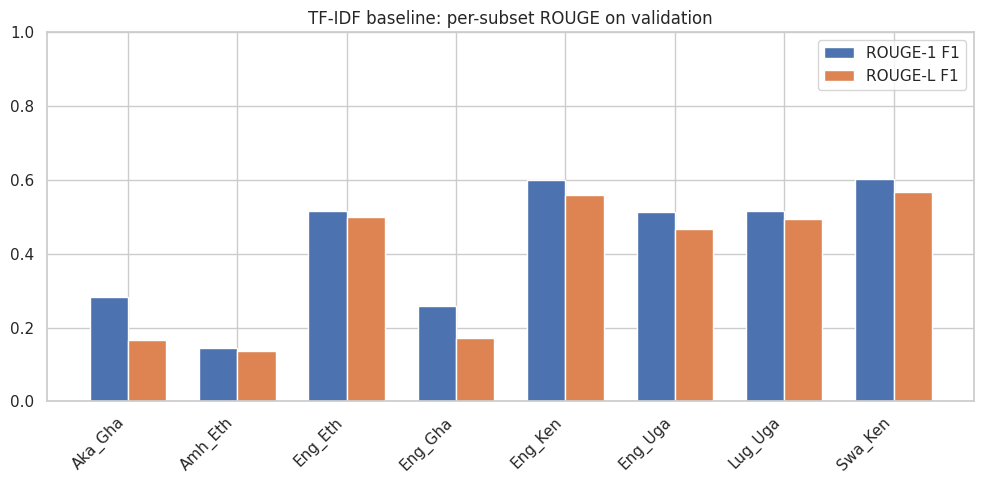

Saved: /content/multilingual-health-qa/figures/eval_tfidf_rouge_by_subset.png


In [14]:
GROUP_COL = LANG_COL
TEST_GROUP_COL = TEST_LANG_COL

print('Training TF-IDF retrieval (E02: per-subset)...')
answerer_valid = TfidfRetrievalAnswerer(
    question_col=QUESTION_COL, answer_col=ANSWER_COL, group_col=GROUP_COL,
).fit(train)

valid_pred, valid_sim, valid_match = answerer_valid.predict(
    val, question_col=QUESTION_COL, group_col=GROUP_COL,
)

if compute_rouge:
    metrics_tfidf = compute_rouge(valid_pred, val[ANSWER_COL].tolist())
    print(f'\nTF-IDF (E02) - Validation ROUGE')
    print(f'   ROUGE-1 F1 : {metrics_tfidf["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics_tfidf["rougeL_f1"]:.4f}')

    lang_metrics = compute_rouge_by_language(valid_pred, val[ANSWER_COL].tolist(), val[LANG_COL].tolist())
    print('\nPer-subset ROUGE:')
    display(lang_metrics.round(4))

    tracker.log(
        experiment_id='E02', name='TF-IDF per-subset retrieval',
        category='baseline',
        change='Char n-gram TF-IDF with per-subset indexes',
        rationale='EDA: subset codes capture country-specific health vocabulary; per-group retrieval avoids cross-language neighbours',
        rouge1=metrics_tfidf['rouge1_f1'], rougel=metrics_tfidf['rougeL_f1'],
    )

preview = val[[ID_COL, QUESTION_COL, ANSWER_COL]].head(5).copy()
preview['baseline_answer'] = valid_pred[:5]
preview['similarity'] = [f'{s:.3f}' for s in valid_sim[:5]]
display(preview)

if compute_rouge and 'lang_metrics' in dir() and not lang_metrics.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = lang_metrics.reset_index().rename(columns={'index': 'subset'})
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w/2, plot_df['rouge1_f1'], w, label='ROUGE-1 F1')
    ax.bar(x + w/2, plot_df['rougeL_f1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['subset'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title('TF-IDF baseline: per-subset ROUGE on validation')
    ax.legend()
    plt.tight_layout()
    path = FIGURES_DIR / 'eval_tfidf_rouge_by_subset.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


In [15]:
print('Training TF-IDF on full train -> test predictions...')
answerer = TfidfRetrievalAnswerer(
    question_col=QUESTION_COL, answer_col=ANSWER_COL, group_col=GROUP_COL,
).fit(train)

test_pred_tfidf, test_sim, _ = answerer.predict(
    test, question_col=TEST_QUESTION_COL, group_col=TEST_GROUP_COL,
)
print(f'Generated {len(test_pred_tfidf)} predictions')

Training TF-IDF on full train -> test predictions...
  Fitted global model + 8 group model(s)
Generated 2618 predictions


## 11 — Baseline 2: Multilingual LLM (Experiment E07)

### Objective

Evaluate zero-shot generative performance as an upper-bound reference for neural generation (without fine-tuning).

### Model

**Default:** `google/mt5-small` — fast multilingual encoder-decoder for prototyping prompts and token limits.

### Inference settings

| Parameter | Default | Notes |
|---|---|---|
| `MAX_INPUT_LENGTH` | 256 | Based on question length distribution |
| `MAX_OUTPUT_LENGTH` | 512 | Based on answer length distribution |
| `NUM_BEAMS` | 4 | Beam search for longer answers |
| `USE_LANGUAGE_PROMPT` | True | Prepends target language to the input |

### Experiment E07

Language-conditioned zero-shot prompt with beam search. Generative baselines are compared against retrieval in Section 12.


In [16]:
import sys
import subprocess
import importlib.util

# Install mT5 tokenizer deps into *this* kernel's Python (before importing transformers).
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '-q', 'protobuf', 'sentencepiece']
)
importlib.invalidate_caches()
import google.protobuf  # noqa: F401
import sentencepiece  # noqa: F401

# transformers caches sentencepiece availability at first import — refresh after install.
import transformers.utils.import_utils as _tf_import_utils
_tf_import_utils._sentencepiece_available = _tf_import_utils._is_package_available('sentencepiece')

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = 'google/mt5-small'

MAX_INPUT_LENGTH  = 256
MAX_OUTPUT_LENGTH = 512
BATCH_SIZE_LLM    = 8
NUM_BEAMS         = 4
USE_LANGUAGE_PROMPT = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')
print(f'Language-conditioned prompts: {USE_LANGUAGE_PROMPT}')

Device : cuda
Model  : google/mt5-small
Language-conditioned prompts: True


In [17]:
print(f'Loading {MODEL_NAME}...')
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
except ValueError as exc:
    if 'protobuf' in str(exc).lower() or 'tiktoken' in str(exc).lower():
        raise RuntimeError(
            'Tokenizer load failed — re-run the cell above to install protobuf + sentencepiece, '
            'then re-run this cell.'
        ) from exc
    raise
model_llm = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
)
model_llm.gradient_checkpointing_enable()
model_llm = model_llm.to(DEVICE)
model_llm.eval()
print(f'Loaded {sum(p.numel() for p in model_llm.parameters()) / 1e6:.0f}M parameters on {DEVICE}')

Loading google/mt5-small...


tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded 300M parameters on cuda


In [18]:
FALLBACK_ANSWER = 'Please consult a healthcare professional for personalised advice.'


def build_prompt(question: str, language: str = None) -> str:
    """
    Build seq2seq input. E07 uses language conditioning because EDA shows
    5 languages with imbalanced counts; explicit language tags reduce
    English-dominance bias during fine-tuning and inference.
    """
    q = str(question).strip()
    if USE_LANGUAGE_PROMPT and language:
        lang_name = subset_to_language_name(language)
        return f'answer health question in {lang_name}: {q}'
    return q


def generate_answers_batch(questions, languages=None, batch_size=BATCH_SIZE_LLM,
                           num_beams=NUM_BEAMS):
    if languages is None:
        languages = [None] * len(questions)
    all_answers = []
    n_batches = (len(questions) + batch_size - 1) // batch_size

    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, len(questions))
        prompts = [build_prompt(q, l) for q, l in zip(questions[start:end], languages[start:end])]

        inputs = tokenizer(
            prompts, return_tensors='pt', padding=True,
            truncation=True, max_length=MAX_INPUT_LENGTH,
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model_llm.generate(
                **inputs,
                max_new_tokens=MAX_OUTPUT_LENGTH,
                min_new_tokens=1,
                num_beams=num_beams,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        cleaned = [re.sub(r'<extra_id_\d+>', '', ans).strip() for ans in decoded]
        cleaned = [ans if ans else FALLBACK_ANSWER for ans in cleaned]
        all_answers.extend(cleaned)

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == n_batches:
            print(f'  Batch {batch_idx + 1}/{n_batches}')

    empty_n = sum(1 for a in all_answers if not str(a).strip())
    if empty_n:
        print(f'WARNING: {empty_n} empty predictions remain after fallback')
    return all_answers

print('Generation helpers defined')

Generation helpers defined


In [19]:
if 'tokenizer' not in globals() or 'model_llm' not in globals():
    raise RuntimeError('Run the model load cell above first (tokenizer / model_llm not defined).')

sample = val.head(3)
gen_sample = generate_answers_batch(
    sample[QUESTION_COL].tolist(),
    sample[LANG_COL].tolist() if LANG_COL else None,
    batch_size=3,
)
for idx, (_, row) in enumerate(sample.iterrows()):
    print(f'\n[{idx+1}] {row[LANG_COL]}')
    print(f'  Q: {row[QUESTION_COL][:100]}...')
    print(f'  Ref: {row[ANSWER_COL][:100]}...')
    print(f'  Gen: {gen_sample[idx][:100]}...')

  Batch 1/1

[1] Aka_Gha
  Q: Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, at...
  Ref: Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ka no 'STEM' ne 'vocational training' se ɛbɛ adrɛse mm...
  Gen: ....

[2] Aka_Gha
  Q: Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo hokwan ahorow ase?...
  Ref: Nna ne awo hokwan ahorow a wɔte ase no ma mmabun tumi: Si gyinae a ɛfata wɔ wɔn nipadua, nna, ne abu...
  Gen: ?...

[3] Aka_Gha
  Q: Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan a etu mpɔn na ahobammɔ wom so, na anammɔn bɛn na metu...
  Ref: Ayayade ho nsɛm a wɔbɛbɔ ho amanneɛ yiye na ahobammɔ wom no hwehwɛ sɛ wɔyɛ nneɛma a edidi so yi: Wɔk...
  Gen: ....


Evaluating zero-shot LLM on 200 val examples...
  Batch 10/25
  Batch 20/25
  Batch 25/25

Zero-shot LLM - Validation ROUGE (google/mt5-small)
   ROUGE-1 F1 : 0.0153
   ROUGE-L F1 : 0.0144
Logged experiment E07: Zero-shot google/mt5-small (E07)


,rouge1_f1,rougeL_f1
Aka_Gha,0.0023,0.0023
Amh_Eth,0.0111,0.0111
Eng_Eth,0.0373,0.0373
Eng_Gha,0.0241,0.0233
Eng_Ken,0.0346,0.0315
Eng_Uga,0.0244,0.0205
Lug_Uga,0.0000,0.0000
Swa_Ken,0.0000,0.0000


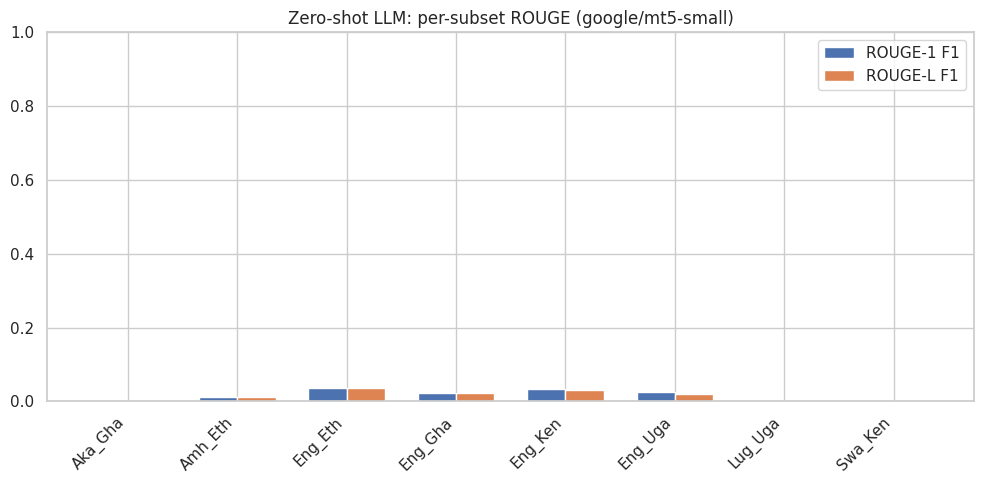

Saved: /content/multilingual-health-qa/figures/eval_zeroshot_rouge_by_subset.png


In [20]:
VALIDATION_SAMPLE_SIZE = 200

val_sample = val.sample(min(VALIDATION_SAMPLE_SIZE, len(val)), random_state=SEED) if VALIDATION_SAMPLE_SIZE else val
print(f'Evaluating zero-shot LLM on {len(val_sample)} val examples...')

val_questions = val_sample[QUESTION_COL].tolist()
val_languages = val_sample[LANG_COL].tolist() if LANG_COL else None
val_references = val_sample[ANSWER_COL].tolist()

val_predictions_llm = generate_answers_batch(val_questions, val_languages)

if compute_rouge:
    metrics_llm = compute_rouge(val_predictions_llm, val_references)
    print(f'\nZero-shot LLM - Validation ROUGE ({MODEL_NAME})')
    print(f'   ROUGE-1 F1 : {metrics_llm["rouge1_f1"]:.4f}')
    print(f'   ROUGE-L F1 : {metrics_llm["rougeL_f1"]:.4f}')

    tracker.log(
        experiment_id='E07',
        name=f'Zero-shot {MODEL_NAME} (E07)',
        change=f'Model={MODEL_NAME}, language_prompt={USE_LANGUAGE_PROMPT}, beams={NUM_BEAMS}',
        category='baseline',
        rationale='EDA: multilingual imbalance -> language-conditioned prompts; long answers -> beam search',
        rouge1=metrics_llm['rouge1_f1'], rougel=metrics_llm['rougeL_f1'],
    )

    llm_lang_metrics = compute_rouge_by_language(val_predictions_llm, val_references, val_sample[LANG_COL].tolist())
    display(llm_lang_metrics.round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = llm_lang_metrics.reset_index().rename(columns={'index': 'subset'})
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w/2, plot_df['rouge1_f1'], w, label='ROUGE-1 F1')
    ax.bar(x + w/2, plot_df['rougeL_f1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['subset'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title(f'Zero-shot LLM: per-subset ROUGE ({MODEL_NAME})')
    ax.legend()
    plt.tight_layout()
    path = FIGURES_DIR / 'eval_zeroshot_rouge_by_subset.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')


In [21]:
print(f'Generating test predictions ({len(test)} rows)...')
test_pred_llm = generate_answers_batch(
    test[TEST_QUESTION_COL].tolist(),
    test[TEST_LANG_COL].tolist() if TEST_LANG_COL else None,
)
print(f'{len(test_pred_llm)} answers generated')

Generating test predictions (2618 rows)...
  Batch 10/328
  Batch 20/328
  Batch 30/328
  Batch 40/328
  Batch 50/328
  Batch 60/328
  Batch 70/328
  Batch 80/328
  Batch 90/328
  Batch 100/328
  Batch 110/328
  Batch 120/328
  Batch 130/328
  Batch 140/328
  Batch 150/328
  Batch 160/328
  Batch 170/328
  Batch 180/328
  Batch 190/328
  Batch 200/328
  Batch 210/328
  Batch 220/328
  Batch 230/328
  Batch 240/328
  Batch 250/328
  Batch 260/328
  Batch 270/328
  Batch 280/328
  Batch 290/328
  Batch 300/328
  Batch 310/328
  Batch 320/328
  Batch 328/328
2618 answers generated


## 12 — Baseline comparison

Compare TF-IDF retrieval (E02) and zero-shot LLM (E07) on a validation sample using ROUGE-1 and ROUGE-L F1.

### Outputs

| File | Description |
|---|---|
| `baseline_comparison.png` | Grouped bar chart of ROUGE scores |
| `baseline_comparison_trend.png` | Line chart of ROUGE trends across baselines |

These results motivate the hybrid retrieval experiments in Section 13.


Baseline comparison on validation sample:


,Approach,ROUGE-1 F1,ROUGE-L F1
0,TF-IDF (E02),0.4135,0.3581
1,Zero-shot LLM (google/mt5-small),0.0153,0.0144


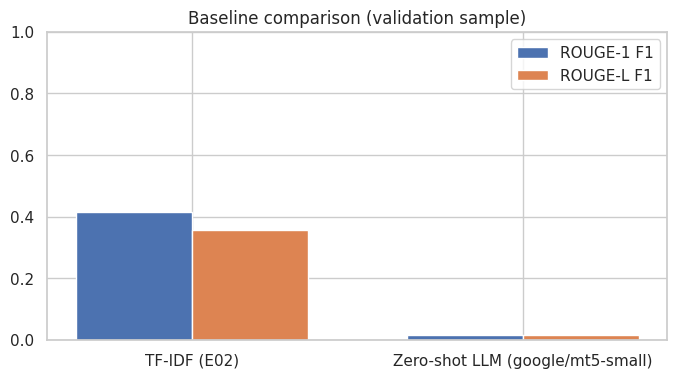

Saved: /content/multilingual-health-qa/figures/baseline_comparison.png


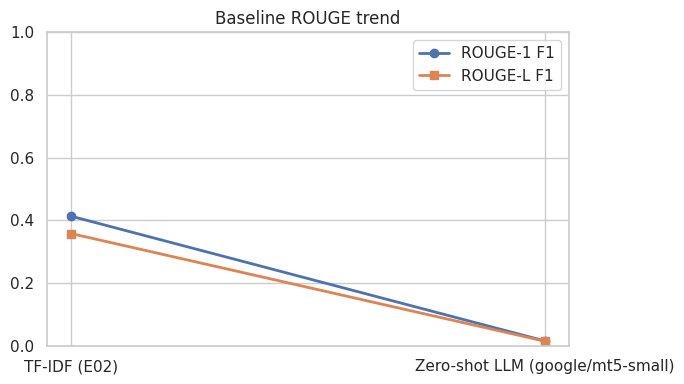

Saved: /content/multilingual-health-qa/figures/baseline_comparison_trend.png


In [22]:
if compute_rouge:
    tfidf_preds_val, _, _ = answerer_valid.predict(val_sample, QUESTION_COL, GROUP_COL)
    metrics_tfidf_cmp = compute_rouge(tfidf_preds_val, val_references)

    comparison = pd.DataFrame({
        'Approach': ['TF-IDF (E02)', f'Zero-shot LLM ({MODEL_NAME})'],
        'ROUGE-1 F1': [metrics_tfidf_cmp['rouge1_f1'], metrics_llm['rouge1_f1']],
        'ROUGE-L F1': [metrics_tfidf_cmp['rougeL_f1'], metrics_llm['rougeL_f1']],
    })
    print('Baseline comparison on validation sample:')
    display(comparison.round(4))

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(comparison))
    w = 0.35
    ax.bar(x - w/2, comparison['ROUGE-1 F1'], w, label='ROUGE-1 F1')
    ax.bar(x + w/2, comparison['ROUGE-L F1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Approach'])
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title('Baseline comparison (validation sample)')
    cmp_path = FIGURES_DIR / 'baseline_comparison.png'
    plt.savefig(cmp_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {cmp_path}')

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(comparison['Approach'], comparison['ROUGE-1 F1'], marker='o', label='ROUGE-1 F1', linewidth=2)
    ax.plot(comparison['Approach'], comparison['ROUGE-L F1'], marker='s', label='ROUGE-L F1', linewidth=2)
    ax.set_ylim(0, 1)
    ax.set_title('Baseline ROUGE trend')
    ax.legend()
    plt.tight_layout()
    trend_path = FIGURES_DIR / 'baseline_comparison_trend.png'
    plt.savefig(trend_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {trend_path}')


## 13 — Advanced retrieval (Experiments E08–E11, E14)

### Approach

The retrieval system returns expert answers from the training corpus rather than generating free text. This aligns with overlap-based evaluation on long, domain-specific answers.

| Step | What it does |
|---|---|
| 1. **Exact / fuzzy duplicate** | If the question ≈ a corpus question (≥92% similar) → return that answer |
| 2. **Sparse retrieval** | Char TF-IDF + BM25 → top-K candidates per subset |
| 3. **Cross-encoder rerank** | Score (question, candidate question) pairs |
| 4. **Min answer length** | Subset-aware threshold; exact/fuzzy matches skip min-length |
| 5. **Answer rerank** | Score (q, a) pairs: CE + token overlap + BM25(answer) + length prior |

Dense embeddings are **off by default** — they tend to select paraphrases that lower ROUGE on this task.

### Experiment iteration map

| Step | ID | Focus |
|---|---|---|
| Final system | E08 | Full hybrid pipeline on train+val index |
| Honest eval | E09 | Train-only index (no val leakage) |
| Sensitivity | E11 | Top-k ablation on a validation sample |
| Diagnostic | E14 | Oracle ceiling (RDA) — not ranked against models |

### Hyperparameters (default)

| Parameter | Value |
|---|---|
| `RETRIEVAL_K` | `50` |
| `RERANK_TOP_N` | `50` |
| `FUZZY_MATCH_THRESHOLD` | `92` (validation) |
| `FUZZY_MATCH_THRESHOLD_TEST` | `88` (test export) |
| `MIN_ANSWER_LENGTH` | `200` default; subset overrides in config cell |

`predict()` reports a match-type breakdown (`exact`, `fuzzy`, `retrieval`, `retrieval_short`) and periodic running ROUGE when references are provided.


In [23]:
# --- Advanced retrieval configuration (Section 13) ---
RETRIEVAL_K              = 50
RERANK_TOP_N             = 50      # score all top-K candidates
NGRAM_RANGE              = (2, 6)
MAX_FEATURES             = 500_000
USE_VAL_IN_INDEX         = True
USE_DENSE_RETRIEVAL      = False   # off — dense hurts ROUGE on this task
SPARSE_WEIGHT            = 0.50
BM25_WEIGHT              = 0.50
DENSE_WEIGHT             = 0.0
DENSE_MODEL_NAME         = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
CROSS_ENCODER_MODEL      = 'cross-encoder/mmarco-mMiniLMv2-L12-H384-v1'
USE_BM25                 = True
USE_CROSS_ENCODER        = True
FUZZY_MATCH_THRESHOLD    = 92      # val / default
FUZZY_MATCH_THRESHOLD_TEST = 88    # lower threshold for test export (more near-dup hits)
MIN_ANSWER_LENGTH        = 200     # default when subset not listed below
SUBSET_MIN_ANSWER_LENGTH = {
    'Amh_Eth': 60,
    'Aka_Gha': 100,
    'Eng_Gha': 100,
}
# Answer-level reranking weights
CE_WEIGHT                = 0.50
ANSWER_RERANK_WEIGHT     = 0.45     # Q→A token overlap
ANSWER_BM25_WEIGHT       = 0.30     # BM25(q, candidate answer)
LENGTH_PRIOR_WEIGHT      = 0.10     # subset median answer length
SPARSE_BLEND_WEIGHT      = 0.05     # retrieval score tie-in
RDA_TOP_K                = 50
RDA_SAMPLE_FAILURES      = 3
ENCODE_BATCH_SIZE        = 128
RETRIEVAL_LOG_EVERY      = 500
ABLATON_SAMPLE_SIZE      = 300

print('Advanced retrieval configuration:')
for k, v in {
    'top_k': RETRIEVAL_K,
    'rerank_n': RERANK_TOP_N,
    'fuzzy_val': FUZZY_MATCH_THRESHOLD,
    'fuzzy_test': FUZZY_MATCH_THRESHOLD_TEST,
    'ce_weight': CE_WEIGHT,
    'answer_overlap': ANSWER_RERANK_WEIGHT,
    'answer_bm25': ANSWER_BM25_WEIGHT,
    'length_prior': LENGTH_PRIOR_WEIGHT,
    'subset_min_lens': SUBSET_MIN_ANSWER_LENGTH,
    'output': str(OUTPUT_RETRIEVAL),
}.items():
    print(f'  {k}: {v}')


Advanced retrieval configuration:
  top_k: 50
  rerank_n: 50
  fuzzy_val: 92
  fuzzy_test: 88
  ce_weight: 0.5
  answer_overlap: 0.45
  answer_bm25: 0.3
  length_prior: 0.1
  subset_min_lens: {'Amh_Eth': 60, 'Aka_Gha': 100, 'Eng_Gha': 100}
  output: /content/multilingual-health-qa/submission_hybrid_retrieval.csv


In [24]:
import re
from collections import Counter
from rank_bm25 import BM25Okapi
from rapidfuzz import fuzz, process
from tqdm.auto import tqdm


def normalize_question(text):
    """Normalize for duplicate / fuzzy matching."""
    t = clean_text(text)
    t = re.sub(r'\s+', ' ', t).strip()
    return t


class AdvancedRetrievalAnswerer:
    """Fuzzy duplicate + TF-IDF + BM25 + cross-encoder + answer-level reranking."""

    def __init__(
        self,
        question_col,
        answer_col,
        id_col='ID',
        group_col=None,
        ngram_range=(2, 6),
        max_features=500_000,
        top_k=30,
        rerank_top_n=15,
        sparse_weight=0.55,
        bm25_weight=0.45,
        dense_weight=0.0,
        dense_model_name='sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
        cross_encoder_model='cross-encoder/mmarco-mMiniLMv2-L12-H384-v1',
        use_dense=False,
        use_bm25=True,
        use_cross_encoder=True,
        fuzzy_threshold=92,
        min_answer_length=200,
        min_answer_length_by_group=None,
        ce_weight=0.50,
        answer_rerank_weight=0.45,
        answer_bm25_weight=0.30,
        length_prior_weight=0.10,
        sparse_blend_weight=0.05,
        encode_batch_size=128,
    ):
        self.question_col = question_col
        self.answer_col = answer_col
        self.id_col = id_col
        self.group_col = group_col
        self.ngram_range = ngram_range
        self.max_features = max_features
        self.top_k = top_k
        self.rerank_top_n = rerank_top_n
        self.sparse_weight = sparse_weight
        self.bm25_weight = bm25_weight
        self.dense_weight = dense_weight
        self.dense_model_name = dense_model_name
        self.cross_encoder_model = cross_encoder_model
        self.use_dense = use_dense
        self.use_bm25 = use_bm25
        self.use_cross_encoder = use_cross_encoder
        self.fuzzy_threshold = fuzzy_threshold
        self.min_answer_length = min_answer_length
        self.min_answer_length_by_group = min_answer_length_by_group or {}
        self.ce_weight = ce_weight
        self.answer_rerank_weight = answer_rerank_weight
        self.answer_bm25_weight = answer_bm25_weight
        self.length_prior_weight = length_prior_weight
        self.sparse_blend_weight = sparse_blend_weight
        self.encode_batch_size = encode_batch_size
        self.encoder = None
        self.cross_encoder = None
        self.models = {}
        self.global_model = None
        self.subset_median_answer_len = {}
        self.last_match_stats = Counter()

    def _min_len_for_group(self, group):
        if group and group in self.min_answer_length_by_group:
            return int(self.min_answer_length_by_group[group])
        return int(self.min_answer_length)

    def _tokenize_bm25(self, text):
        t = normalize_question(text)
        if not t:
            return []
        return t.split()

    def _answer_overlap_score(self, question, answer):
        q_tokens = set(self._tokenize_bm25(question))
        a_tokens = set(self._tokenize_bm25(answer))
        if not q_tokens or not a_tokens:
            return 0.0
        return len(q_tokens & a_tokens) / len(q_tokens)

    def _bm25_answer_score(self, question, answer):
        q_tokens = self._tokenize_bm25(question)
        a_tokens = self._tokenize_bm25(answer)
        if not q_tokens or not a_tokens:
            return 0.0
        bm = BM25Okapi([a_tokens])
        raw = float(bm.get_scores(q_tokens)[0])
        return raw / (len(q_tokens) + 1.0)

    def _length_prior(self, group, answer_len):
        target = float(self.subset_median_answer_len.get(group, 400))
        if target <= 0:
            return 0.0
        return max(0.0, 1.0 - abs(answer_len - target) / target)

    def _get_cross_encoder(self):
        if self.cross_encoder is None:
            from sentence_transformers import CrossEncoder
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f'  Loading cross-encoder: {self.cross_encoder_model} ({device})')
            self.cross_encoder = CrossEncoder(self.cross_encoder_model, device=device)
        return self.cross_encoder

    def _get_encoder(self):
        if self.encoder is None:
            from sentence_transformers import SentenceTransformer
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f'  Loading dense encoder: {self.dense_model_name} ({device})')
            self.encoder = SentenceTransformer(self.dense_model_name, device=device)
        return self.encoder

    def _fit_single(self, df):
        questions = df[self.question_col].fillna('').astype(str).tolist()
        answers = df[self.answer_col].fillna('').astype(str).tolist()
        ids = (
            df[self.id_col].fillna('').astype(str).tolist()
            if self.id_col in df.columns else [''] * len(questions)
        )
        norms = [normalize_question(q) for q in questions]

        norm_to_idx = {}
        for i, nq in enumerate(norms):
            if nq and nq not in norm_to_idx:
                norm_to_idx[nq] = i

        vectorizer = TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=self.ngram_range,
            min_df=1,
            max_features=self.max_features,
            lowercase=False,
        )
        X_sparse = vectorizer.fit_transform(questions)
        k = min(self.top_k, len(questions))
        nn_sparse = NearestNeighbors(n_neighbors=k, metric='cosine')
        nn_sparse.fit(X_sparse)

        bm25 = None
        if self.use_bm25 and len(questions) >= 2:
            tokenized = [self._tokenize_bm25(q) for q in questions]
            tokenized = [t if t else [''] for t in tokenized]
            bm25 = BM25Okapi(tokenized)

        model = {
            'vectorizer': vectorizer,
            'nn_sparse': nn_sparse,
            'bm25': bm25,
            'answers': np.array(answers, dtype=object),
            'questions': np.array(questions, dtype=object),
            'ids': np.array(ids, dtype=object),
            'norms': np.array(norms, dtype=object),
            'norm_to_idx': norm_to_idx,
            'k': k,
        }

        if self.use_dense and len(questions) >= 2:
            encoder = self._get_encoder()
            embeddings = encoder.encode(
                questions,
                batch_size=self.encode_batch_size,
                show_progress_bar=len(questions) > 5000,
                normalize_embeddings=True,
            )
            nn_dense = NearestNeighbors(n_neighbors=k, metric='cosine')
            nn_dense.fit(embeddings)
            model['embeddings'] = embeddings
            model['nn_dense'] = nn_dense

        return model

    def fit(self, df):
        self.global_model = self._fit_single(df)
        self.models = {}
        if self.group_col and self.group_col in df.columns:
            for group, sub in df.groupby(self.group_col):
                if len(sub) >= 2:
                    self.models[group] = self._fit_single(sub)
            self.subset_median_answer_len = (
                df.groupby(self.group_col)[self.answer_col]
                .apply(lambda s: s.astype(str).str.len().median())
                .to_dict()
            )
        else:
            self.subset_median_answer_len = {
                '_global': float(df[self.answer_col].astype(str).str.len().median())
            }
        print(f'  Fitted global index + {len(self.models)} per-subset index(es)')
        return self

    def _refit_neighbors(self, model, new_k):
        import copy
        m = copy.copy(model)
        n = len(m['questions'])
        k = min(new_k, n)
        questions = m['questions'].tolist()
        X_sparse = m['vectorizer'].transform(questions)
        nn_sparse = NearestNeighbors(n_neighbors=k, metric='cosine')
        nn_sparse.fit(X_sparse)
        m['nn_sparse'] = nn_sparse
        m['k'] = k
        if self.use_dense and 'embeddings' in m:
            nn_dense = NearestNeighbors(n_neighbors=k, metric='cosine')
            nn_dense.fit(m['embeddings'])
            m['nn_dense'] = nn_dense
        return m

    def with_top_k(self, new_k):
        import copy
        other = copy.copy(self)
        other.top_k = new_k
        other.global_model = self._refit_neighbors(self.global_model, new_k)
        other.models = {g: self._refit_neighbors(m, new_k) for g, m in self.models.items()}
        other.encoder = self.encoder
        other.cross_encoder = self.cross_encoder
        other.subset_median_answer_len = dict(self.subset_median_answer_len)
        return other

    def _fuzzy_lookup(self, question, model, exclude_id):
        nq = normalize_question(question)
        if not nq:
            return None

        if nq in model['norm_to_idx']:
            idx = model['norm_to_idx'][nq]
            if not exclude_id or str(model['ids'][idx]) != str(exclude_id):
                ans = model['answers'][idx]
                return ans, 1.0, model['questions'][idx], 'exact'

        corpus_norms = model['norms'].tolist()
        match = process.extractOne(
            nq,
            corpus_norms,
            scorer=fuzz.ratio,
            score_cutoff=self.fuzzy_threshold,
        )
        if match is None:
            return None
        _choice, score, idx = match
        if exclude_id and str(model['ids'][idx]) == str(exclude_id):
            return None
        ans = model['answers'][idx]
        return ans, score / 100.0, model['questions'][idx], 'fuzzy'

    def _sparse_candidates(self, question, model, exclude_id):
        k = model['k']
        scores = {}

        Xq = model['vectorizer'].transform([question])
        dist_s, idx_s = model['nn_sparse'].kneighbors(Xq, n_neighbors=k)
        for d, i in zip(dist_s[0], idx_s[0]):
            i = int(i)
            if exclude_id and str(model['ids'][i]) == str(exclude_id):
                continue
            scores[i] = scores.get(i, 0.0) + self.sparse_weight * (1.0 - float(d))

        if model['bm25'] is not None:
            tokens = self._tokenize_bm25(question)
            if not tokens:
                tokens = ['']
            bm_scores = model['bm25'].get_scores(tokens)
            if len(bm_scores):
                mx = float(np.max(bm_scores)) or 1.0
                top_bm = np.argsort(bm_scores)[::-1][:k]
                for i in top_bm:
                    i = int(i)
                    if exclude_id and str(model['ids'][i]) == str(exclude_id):
                        continue
                    scores[i] = scores.get(i, 0.0) + self.bm25_weight * (float(bm_scores[i]) / mx)

        if self.use_dense and 'nn_dense' in model:
            encoder = self._get_encoder()
            q_emb = encoder.encode([question], normalize_embeddings=True, show_progress_bar=False)
            dist_d, idx_d = model['nn_dense'].kneighbors(q_emb, n_neighbors=k)
            for d, i in zip(dist_d[0], idx_d[0]):
                i = int(i)
                if exclude_id and str(model['ids'][i]) == str(exclude_id):
                    continue
                scores[i] = scores.get(i, 0.0) + self.dense_weight * (1.0 - float(d))

        if not scores:
            i = int(idx_s[0][0])
            return [i], {i: 1.0 - float(dist_s[0][0])}

        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [i for i, _ in ranked], dict(ranked)

    def get_neighbors(self, question, group=None, exclude_id=None):
        model = self.models.get(group, self.global_model) if group is not None else self.global_model
        indices, score_map = self._sparse_candidates(question, model, exclude_id)
        return indices, score_map, model

    def _expand_conflict_candidates(self, question, model, candidate_indices):
        """If a neighbour question repeats in the corpus, include all answer variants."""
        nq = normalize_question(question)
        expanded = list(candidate_indices)
        seen = set(expanded)
        for idx in candidate_indices:
            q_norm = model['norms'][idx]
            if not q_norm:
                continue
            for j, other_norm in enumerate(model['norms']):
                j = int(j)
                if j not in seen and other_norm == q_norm:
                    expanded.append(j)
                    seen.add(j)
        return expanded

    def _pick_from_candidates(self, question, model, candidate_indices, score_map, group=None):
        min_len = self._min_len_for_group(group)
        rerank_n = min(self.rerank_top_n, len(candidate_indices))
        pool = self._expand_conflict_candidates(question, model, candidate_indices[:rerank_n])

        ce_norm = {}
        if self.use_cross_encoder and len(pool) > 0:
            ce = self._get_cross_encoder()
            pairs = [(question, str(model['questions'][i])) for i in pool]
            raw_ce = ce.predict(pairs)
            ce_max = float(np.max(raw_ce)) if len(raw_ce) else 1.0
            ce_max = ce_max or 1.0
            ce_norm = {int(i): float(s) / ce_max for i, s in zip(pool, raw_ce)}

        scored = []
        for idx in pool:
            ans = str(model['answers'][idx])
            ans_len = len(ans)
            sparse = float(score_map.get(idx, 0.0))
            combined = (
                self.ce_weight * ce_norm.get(idx, 0.0)
                + self.answer_rerank_weight * self._answer_overlap_score(question, ans)
                + self.answer_bm25_weight * self._bm25_answer_score(question, ans)
                + self.length_prior_weight * self._length_prior(group, ans_len)
                + self.sparse_blend_weight * sparse
            )
            scored.append((idx, combined, ans_len))

        scored.sort(key=lambda x: x[1], reverse=True)

        for idx, combined, ans_len in scored:
            if ans_len >= min_len:
                return model['answers'][idx], combined, model['questions'][idx], 'retrieval'

        if scored:
            idx, combined, _ = scored[0]
            return model['answers'][idx], combined, model['questions'][idx], 'retrieval_short'

        idx = candidate_indices[0]
        return model['answers'][idx], score_map.get(idx, 0.0), model['questions'][idx], 'retrieval_short'

    def _predict_one_from_model(self, question, model, exclude_id=None, group=None):
        fuzzy = self._fuzzy_lookup(question, model, exclude_id)
        if fuzzy is not None:
            return fuzzy

        indices, score_map = self._sparse_candidates(question, model, exclude_id)
        return self._pick_from_candidates(question, model, indices, score_map, group=group)

    def predict_one(self, question, group=None, exclude_id=None):
        model = self.models.get(group, self.global_model) if group is not None else self.global_model
        return self._predict_one_from_model(question, model, exclude_id=exclude_id, group=group)

    def predict(
        self,
        df,
        question_col,
        group_col=None,
        id_col=None,
        references=None,
        log_every=500,
        desc='Retrieval',
        show_progress=True,
    ):
        outputs, similarities, matched, match_types = [], [], [], []
        stats = Counter()
        id_col = id_col or self.id_col
        iterator = df.iterrows()
        if show_progress:
            iterator = tqdm(iterator, total=len(df), desc=desc)

        for i, (_, row) in enumerate(iterator):
            question = clean_text(row[question_col])
            group = row[group_col] if group_col and group_col in df.columns else None
            exclude_id = row[id_col] if id_col and id_col in df.columns else None
            answer, sim, matched_q, mtype = self.predict_one(question, group, exclude_id=exclude_id)
            outputs.append(answer)
            similarities.append(sim)
            matched.append(matched_q)
            match_types.append(mtype)
            stats[mtype] += 1

            if references is not None and compute_rouge and log_every and (i + 1) % log_every == 0:
                partial = compute_rouge(outputs, references[: len(outputs)])
                msg = (
                    f'  [{i + 1:,}/{len(df):,}] R1={partial["rouge1_f1"]:.4f} '
                    f'RL={partial["rougeL_f1"]:.4f} | {dict(stats)} | '
                    f'mean_sim={np.mean(similarities):.3f}'
                )
                if show_progress:
                    tqdm.write(msg)
                else:
                    print(msg)

        self.last_match_stats = stats
        print(f'\\nMatch breakdown ({len(df):,} rows): {dict(stats)}')
        return outputs, similarities, matched


HybridRetrievalAnswerer = AdvancedRetrievalAnswerer
print('AdvancedRetrievalAnswerer defined')


AdvancedRetrievalAnswerer defined


### Experiment E08 — Hybrid retrieval (final system)

**Objective**  
Combine duplicate matching, sparse retrieval, cross-encoder reranking, and answer-level scoring.

**Hypothesis**  
Selecting the best corpus answer (not generating text) maximises ROUGE when references are drawn from the same expert-answer distribution.

**Method**  
Index `Train.csv` + `Val.csv` per subset; fuzzy + BM25 + TF-IDF candidates; cross-encoder and answer-level reranking.

**Evaluation**  
Full validation set; ROUGE-1 and ROUGE-L F1.


In [25]:
import time

retrieval_corpus = pd.concat([train, val], ignore_index=True) if USE_VAL_IN_INDEX else train.copy()
print(f'Building advanced retrieval index on {len(retrieval_corpus):,} Q&A pairs...')

t0 = time.time()
hybrid_answerer = AdvancedRetrievalAnswerer(
    question_col=QUESTION_COL,
    answer_col=ANSWER_COL,
    id_col='ID',
    group_col=LANG_COL,
    ngram_range=NGRAM_RANGE,
    max_features=MAX_FEATURES,
    top_k=RETRIEVAL_K,
    rerank_top_n=RERANK_TOP_N,
    sparse_weight=SPARSE_WEIGHT,
    bm25_weight=BM25_WEIGHT,
    dense_weight=DENSE_WEIGHT,
    dense_model_name=DENSE_MODEL_NAME,
    cross_encoder_model=CROSS_ENCODER_MODEL,
    use_dense=USE_DENSE_RETRIEVAL,
    use_bm25=USE_BM25,
    use_cross_encoder=USE_CROSS_ENCODER,
    fuzzy_threshold=FUZZY_MATCH_THRESHOLD,
    min_answer_length=MIN_ANSWER_LENGTH,
    min_answer_length_by_group=SUBSET_MIN_ANSWER_LENGTH,
    ce_weight=CE_WEIGHT,
    answer_rerank_weight=ANSWER_RERANK_WEIGHT,
    answer_bm25_weight=ANSWER_BM25_WEIGHT,
    length_prior_weight=LENGTH_PRIOR_WEIGHT,
    sparse_blend_weight=SPARSE_BLEND_WEIGHT,
    encode_batch_size=ENCODE_BATCH_SIZE,
).fit(retrieval_corpus)
fit_min = (time.time() - t0) / 60
print(f'Index built in {fit_min:.1f} min')

if compute_rouge:
    print(f'\nEvaluating advanced retrieval on Val.csv ({len(val):,} rows)...')
    t1 = time.time()
    val_pred_hybrid, val_sim_hybrid, _ = hybrid_answerer.predict(
        val,
        question_col=QUESTION_COL,
        group_col=LANG_COL,
        id_col='ID',
        references=val[ANSWER_COL].tolist(),
        log_every=RETRIEVAL_LOG_EVERY,
        desc='Val retrieval',
    )
    eval_min = (time.time() - t1) / 60
    metrics_hybrid = print_run_summary(
        'Hybrid retrieval (E08) — Validation',
        val_pred_hybrid,
        val[ANSWER_COL].tolist(),
        languages=val[LANG_COL].tolist(),
        min_answer_len=MIN_ANSWER_LENGTH,
    )
    print(f'  Mean similarity : {np.mean(val_sim_hybrid):.4f}')
    print(f'  Inference time  : {eval_min:.1f} min')

    tracker.log(
        experiment_id='E08',
        name='Hybrid retrieval (final)',
        category='retrieval',
        change=f'k={RETRIEVAL_K}, CE={CE_WEIGHT}, aq={ANSWER_RERANK_WEIGHT}, abm={ANSWER_BM25_WEIGHT}',
        rationale='Duplicate match, sparse retrieval, cross-encoder and answer-level reranking',
        rouge1=metrics_hybrid['rouge1_f1'],
        rougel=metrics_hybrid['rougeL_f1'],
        runtime_min=round(fit_min + eval_min, 1),
        notes=f'match_stats={dict(hybrid_answerer.last_match_stats)}',
    )
    hybrid_lang = compute_rouge_by_language(
        val_pred_hybrid, val[ANSWER_COL].tolist(), val[LANG_COL].tolist(),
    )
else:
    print('ROUGE not available — skipping validation eval')


Building advanced retrieval index on 36,216 Q&A pairs...
  Fitted global index + 8 per-subset index(es)
Index built in 0.3 min

Evaluating advanced retrieval on Val.csv (6,686 rows)...


Val retrieval:   0%|          | 0/6686 [00:00<?, ?it/s]

  Loading cross-encoder: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1 (cuda)


config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  [500/6,686] R1=0.3132 RL=0.1858 | {'retrieval': 500} | mean_sim=0.729
  [1,000/6,686] R1=0.3053 RL=0.1800 | {'retrieval': 1000} | mean_sim=0.729
  [1,500/6,686] R1=0.2606 RL=0.1652 | {'retrieval': 1500} | mean_sim=1.133
  [2,000/6,686] R1=0.2721 RL=0.1938 | {'retrieval': 1919, 'retrieval_short': 53, 'exact': 28} | mean_sim=0.883
  [2,500/6,686] R1=0.2797 RL=0.2024 | {'retrieval': 2371, 'retrieval_short': 78, 'exact': 51} | mean_sim=0.960
  [3,000/6,686] R1=0.2773 RL=0.1984 | {'retrieval': 2871, 'retrieval_short': 78, 'exact': 51} | mean_sim=1.570
  [3,500/6,686] R1=0.2971 RL=0.2199 | {'retrieval': 3371, 'retrieval_short': 78, 'exact': 51} | mean_sim=1.684
  [4,000/6,686] R1=0.3304 RL=0.2580 | {'retrieval': 3871, 'retrieval_short': 78, 'exact': 51} | mean_sim=1.907
  [4,500/6,686] R1=0.3562 RL=0.2872 | {'retrieval': 4368, 'retrieval_short': 78, 'exact': 54} | mean_sim=2.072
  [5,000/6,686] R1=0.3727 RL=0.3061 | {'retrieval': 4861, 'retrieval_short': 78, 'exact': 61} | mean_sim=2.105
 

,rouge1_f1,rougeL_f1
Aka_Gha,0.3045,0.1793
Amh_Eth,0.1316,0.1228
Eng_Eth,0.3555,0.3257
Eng_Gha,0.2689,0.1795
Eng_Ken,0.5531,0.5117
Eng_Uga,0.5513,0.5094
Lug_Uga,0.3732,0.3407
Swa_Ken,0.5985,0.5629


  Mean similarity : 1.9656
  Inference time  : 26.1 min
Logged experiment E08: Hybrid retrieval (final)


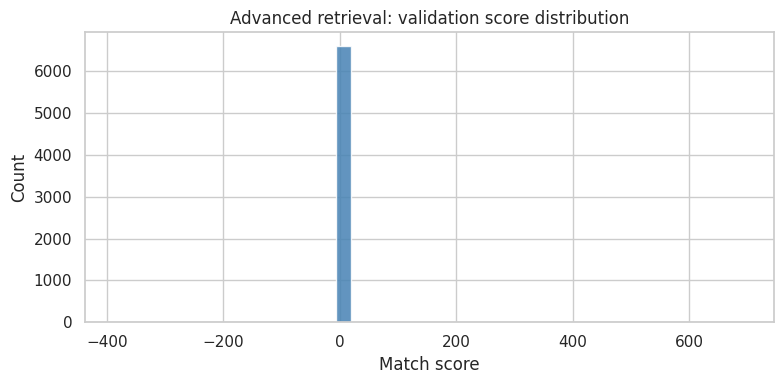

Saved: /content/multilingual-health-qa/figures/retrieval_similarity_hist.png


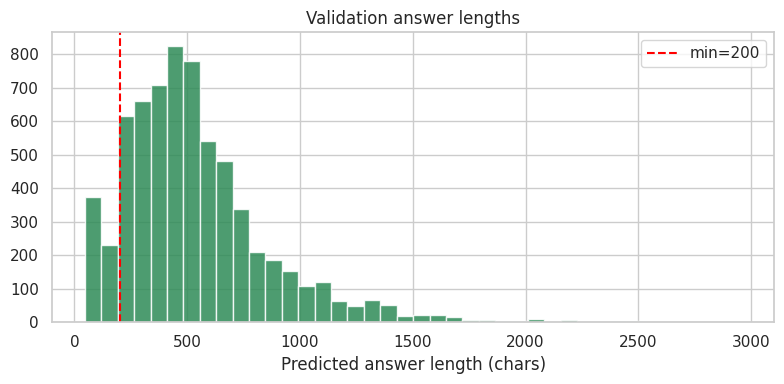

Saved: /content/multilingual-health-qa/figures/retrieval_answer_length_hist.png


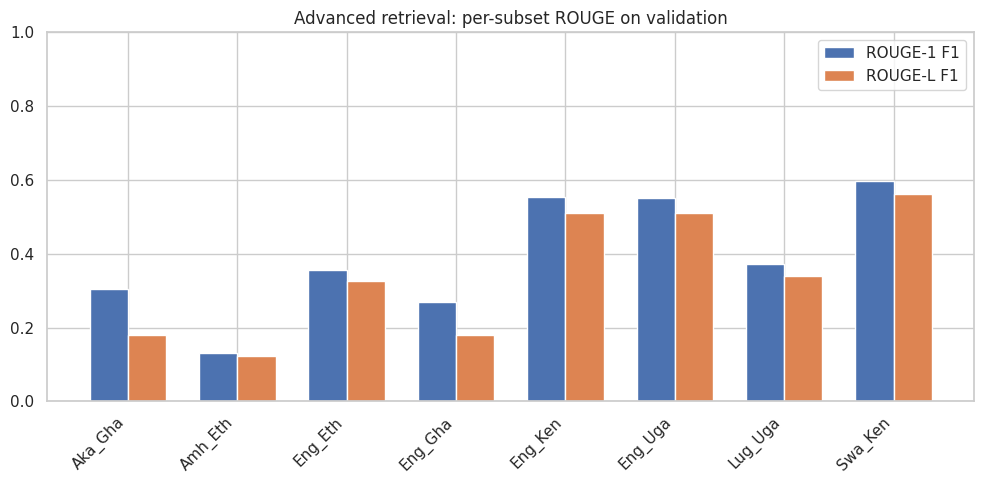

Saved: /content/multilingual-health-qa/figures/retrieval_rouge_by_subset.png


In [26]:
if compute_rouge and 'val_sim_hybrid' in dir():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(val_sim_hybrid, bins=40, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Match score')
    ax.set_ylabel('Count')
    ax.set_title('Advanced retrieval: validation score distribution')
    plt.tight_layout()
    sim_path = FIGURES_DIR / 'retrieval_similarity_hist.png'
    plt.savefig(sim_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {sim_path}')

    ans_lens = [len(str(p)) for p in val_pred_hybrid]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(ans_lens, bins=40, color='seagreen', alpha=0.85, edgecolor='white')
    ax.axvline(MIN_ANSWER_LENGTH, color='red', linestyle='--', label=f'min={MIN_ANSWER_LENGTH}')
    ax.set_xlabel('Predicted answer length (chars)')
    ax.set_title('Validation answer lengths')
    ax.legend()
    plt.tight_layout()
    len_path = FIGURES_DIR / 'retrieval_answer_length_hist.png'
    plt.savefig(len_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {len_path}')

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = hybrid_lang.reset_index().rename(columns={'index': 'subset'})
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w/2, plot_df['rouge1_f1'], w, label='ROUGE-1 F1')
    ax.bar(x + w/2, plot_df['rougeL_f1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['subset'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title('Advanced retrieval: per-subset ROUGE on validation')
    plt.tight_layout()
    rouge_path = FIGURES_DIR / 'retrieval_rouge_by_subset.png'
    plt.savefig(rouge_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {rouge_path}')
else:
    print('Run the previous cell first.')


### Experiment E11 — Top-k ablation

**Objective**  
Measure sensitivity to neighbour pool size on a validation sample.

**Conclusion**  
Production configuration uses `RETRIEVAL_K=50` (see ablation plot).


Running top-k ablation (E11) on validation sample...


Retrieval:   0%|          | 0/300 [00:00<?, ?it/s]

\nMatch breakdown (300 rows): {'retrieval': 281, 'retrieval_short': 15, 'exact': 4}


Retrieval:   0%|          | 0/300 [00:00<?, ?it/s]

\nMatch breakdown (300 rows): {'retrieval': 285, 'exact': 4, 'retrieval_short': 11}


...

\nMatch breakdown (300 rows): {'retrieval': 288, 'exact': 4, 'retrieval_short': 8}


Retrieval:   0%|          | 0/300 [00:00<?, ?it/s]

\nMatch breakdown (300 rows): {'retrieval': 291, 'exact': 4, 'retrieval_short': 5}


,top_k,rouge1_f1,rougeL_f1
0,5,0.3954,0.3367
1,10,0.3812,0.3224
2,15,0.3868,0.3289
3,20,0.3809,0.3238


Logged experiment E11: Top-k ablation


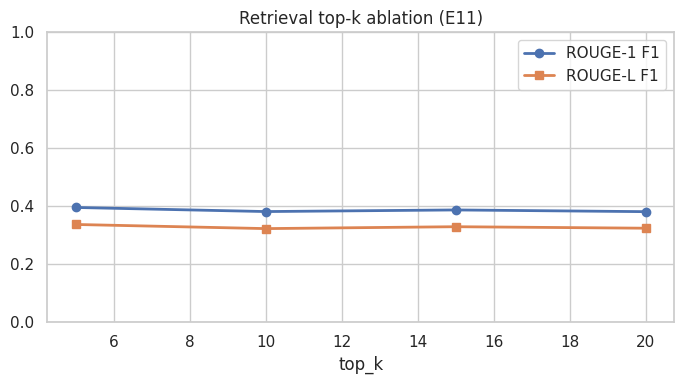

Saved: /content/multilingual-health-qa/figures/retrieval_k_ablation.png


In [27]:
def retrieval_k_ablation(val_df, k_values=(5, 10, 15, 20), sample_size=ABLATON_SAMPLE_SIZE):
    if not compute_rouge:
        return pd.DataFrame()
    subset = val_df.sample(min(sample_size, len(val_df)), random_state=SEED)
    rows = []
    for k in k_values:
        ablator = hybrid_answerer.with_top_k(k)
        preds, _, _ = ablator.predict(subset, QUESTION_COL, LANG_COL, id_col='ID')
        m = compute_rouge(preds, subset[ANSWER_COL].tolist())
        rows.append({'top_k': k, 'rouge1_f1': m['rouge1_f1'], 'rougeL_f1': m['rougeL_f1']})
    return pd.DataFrame(rows)


if compute_rouge and 'hybrid_answerer' in dir():
    print('Running top-k ablation (E11) on validation sample...')
    k_df = retrieval_k_ablation(val)
    display(k_df.round(4))

    if not k_df.empty:
        best = k_df.loc[k_df['rouge1_f1'].idxmax()]
        tracker.log(
            experiment_id='E11',
            name='Top-k ablation',
            category='analysis',
            change=f'Compared k in {list(k_df["top_k"])}; production k={RETRIEVAL_K}',
            rationale='Wider neighbour pool vs noise trade-off',
            rouge1=float(best['rouge1_f1']),
            rougel=float(best['rougeL_f1']),
            notes=k_df.round(4).to_json(orient='records'),
        )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(k_df['top_k'], k_df['rouge1_f1'], marker='o', label='ROUGE-1 F1', linewidth=2)
    ax.plot(k_df['top_k'], k_df['rougeL_f1'], marker='s', label='ROUGE-L F1', linewidth=2)
    ax.set_xlabel('top_k')
    ax.set_ylim(0, 1)
    ax.set_title('Retrieval top-k ablation (E11)')
    ax.legend()
    plt.tight_layout()
    k_path = FIGURES_DIR / 'retrieval_k_ablation.png'
    plt.savefig(k_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {k_path}')
else:
    print('Hybrid answerer not ready — run the E08 cell first.')


### Experiment E09 — Train-only retrieval index

**Objective**  
Measure validation performance without indexing validation questions (honest local evaluation).

**Hypothesis**  
Including `Val.csv` in the index inflates local ROUGE; train-only scores approximate generalisation more conservatively.

**Method**  
Same pipeline as E08, but index `Train.csv` only.

**Evaluation**  
Full validation set.


In [28]:
if not compute_rouge:
    print('ROUGE utilities not loaded — run Section 8 first.')
elif 'hybrid_answerer' not in dir():
    print('Run the E08 retrieval cell first.')
else:
    print('E09 — train-only index (honest val comparison)...')
    train_only = AdvancedRetrievalAnswerer(
        question_col=QUESTION_COL, answer_col=ANSWER_COL, id_col='ID',
        group_col=LANG_COL, ngram_range=NGRAM_RANGE, max_features=MAX_FEATURES,
        top_k=RETRIEVAL_K, rerank_top_n=RERANK_TOP_N,
        sparse_weight=SPARSE_WEIGHT, bm25_weight=BM25_WEIGHT,
        use_dense=USE_DENSE_RETRIEVAL, use_bm25=USE_BM25,
        use_cross_encoder=USE_CROSS_ENCODER, cross_encoder_model=CROSS_ENCODER_MODEL,
        fuzzy_threshold=FUZZY_MATCH_THRESHOLD, min_answer_length=MIN_ANSWER_LENGTH,
        min_answer_length_by_group=SUBSET_MIN_ANSWER_LENGTH,
        ce_weight=CE_WEIGHT, answer_rerank_weight=ANSWER_RERANK_WEIGHT,
        answer_bm25_weight=ANSWER_BM25_WEIGHT, length_prior_weight=LENGTH_PRIOR_WEIGHT,
        sparse_blend_weight=SPARSE_BLEND_WEIGHT, encode_batch_size=ENCODE_BATCH_SIZE,
    )
    train_only.cross_encoder = hybrid_answerer.cross_encoder
    train_only.fit(train)
    val_pred_trainonly, _, _ = train_only.predict(
        val, QUESTION_COL, LANG_COL, id_col='ID',
        references=val[ANSWER_COL].tolist(),
        log_every=RETRIEVAL_LOG_EVERY,
        desc='Val (train-only index)',
    )
    m_train = print_run_summary(
        'E09 train-only index',
        val_pred_trainonly,
        val[ANSWER_COL].tolist(),
        languages=val[LANG_COL].tolist(),
        min_answer_len=MIN_ANSWER_LENGTH,
    )
    tracker.log(
        experiment_id='E09',
        name='Advanced retrieval (train-only index)',
        category='retrieval',
        change='Index Train.csv only',
        rationale='Honest val eval without val-in-index leakage',
        rouge1=m_train['rouge1_f1'], rougel=m_train['rougeL_f1'],
    )


E09 — train-only index (honest val comparison)...
  Fitted global index + 8 per-subset index(es)


Val (train-only index):   0%|          | 0/6686 [00:00<?, ?it/s]

  [500/6,686] R1=0.3048 RL=0.1801 | {'retrieval': 497, 'fuzzy': 3} | mean_sim=0.739
  [1,000/6,686] R1=0.3001 RL=0.1766 | {'retrieval': 995, 'fuzzy': 5} | mean_sim=0.739
  [1,500/6,686] R1=0.2565 RL=0.1624 | {'retrieval': 1479, 'fuzzy': 21} | mean_sim=1.289
  [2,000/6,686] R1=0.2653 RL=0.1877 | {'retrieval': 1869, 'fuzzy': 79, 'retrieval_short': 52} | mean_sim=1.004
  [2,500/6,686] R1=0.2693 RL=0.1923 | {'retrieval': 2325, 'fuzzy': 107, 'retrieval_short': 68} | mean_sim=1.154
  [3,000/6,686] R1=0.2677 RL=0.1893 | {'retrieval': 2815, 'fuzzy': 117, 'retrieval_short': 68} | mean_sim=1.757
  [3,500/6,686] R1=0.2865 RL=0.2096 | {'retrieval': 3309, 'fuzzy': 123, 'retrieval_short': 68} | mean_sim=1.845
  [4,000/6,686] R1=0.3154 RL=0.2430 | {'retrieval': 3678, 'fuzzy': 254, 'retrieval_short': 68} | mean_sim=2.078
  [4,500/6,686] R1=0.3384 RL=0.2695 | {'retrieval': 3997, 'fuzzy': 435, 'retrieval_short': 68} | mean_sim=2.178
  [5,000/6,686] R1=0.3552 RL=0.2888 | {'retrieval': 4313, 'fuzzy': 619,

,rouge1_f1,rougeL_f1
Aka_Gha,0.2999,0.1761
Amh_Eth,0.1296,0.1211
Eng_Eth,0.3218,0.2902
Eng_Gha,0.2648,0.1765
Eng_Ken,0.5311,0.4869
Eng_Uga,0.5119,0.4694
Lug_Uga,0.3455,0.3135
Swa_Ken,0.5540,0.5152


Logged experiment E09: Advanced retrieval (train-only index)


### Diagnostic E14 — Retrieval Diagnostic Analysis (RDA)

RDA measures how much validation ROUGE is recoverable from the cleaned training corpus.

| Metric | Meaning |
|---|---|
| **Fuzzy@1** | Best fuzzy similarity: val question → nearest train question (same subset) |
| **Oracle-1** | ROUGE-1 if we return the nearest train answer (sparse top-1) |
| **Oracle-K** | ROUGE-1 if we pick the best answer among top-K train neighbours (ceiling) |
| **System** | ROUGE-1 from E08 hybrid retrieval |
| **Headroom** | Oracle-K − System — recoverable gap from better answer selection |

Uses a **train-only** index on the deduplicated `train` dataframe.

**Figures:** `rda_similarity_hist.png`, `rda_oracle_vs_system.png`, `rda_headroom_by_subset.png`


RDA — Retrieval Diagnostic Analysis on 6,686 val rows (train-only index, n=29,530)...
Building train-only diagnostic index...
  Fitted global index + 8 per-subset index(es)
Comparing against hybrid retrieval predictions.


RDA:   0%|          | 0/6686 [00:00<?, ?it/s]


RDA summary (overall):


,value
n,6686.0000
fuzz_sim_mean,72.1865
oracle_1_mean,0.4063
oracle_k_mean,0.6768
conflict_rate,0.0390
system_r1_mean,0.3993
headroom_mean,0.2775



RDA summary by subset:


,n,fuzz_sim_mean,oracle_1_mean,oracle_k_mean,conflict_rate,system_r1_mean,headroom_mean
subset,,,,,,,
Aka_Gha,1114,63.5488,0.2909,0.4064,0.0000,0.3045,0.1020
Amh_Eth,462,62.5057,0.1511,0.3086,0.0000,0.1316,0.1770
Eng_Eth,564,79.1800,0.5224,0.7476,0.2624,0.3555,0.3920
Eng_Gha,1104,66.3784,0.2608,0.3821,0.0072,0.2689,0.1132
Eng_Ken,390,68.5111,0.5658,0.8971,0.0718,0.5531,0.3441
Eng_Uga,1688,82.5722,0.4939,0.9134,0.0456,0.5513,0.3621
Lug_Uga,846,72.6691,0.4503,0.8634,0.0000,0.3732,0.4902
Swa_Ken,518,72.2956,0.5885,0.8958,0.0000,0.5985,0.2972


Saved: /content/multilingual-health-qa/figures/rda_similarity_hist.png


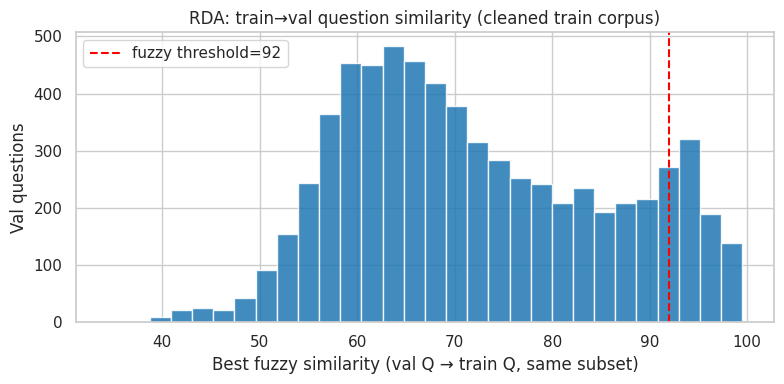

Saved: /content/multilingual-health-qa/figures/rda_oracle_vs_system.png


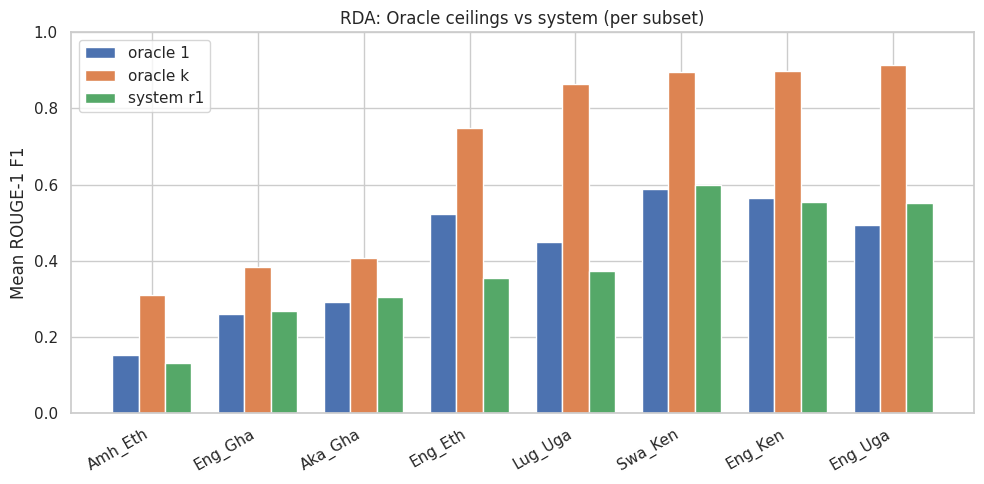

Saved: /content/multilingual-health-qa/figures/rda_headroom_by_subset.png


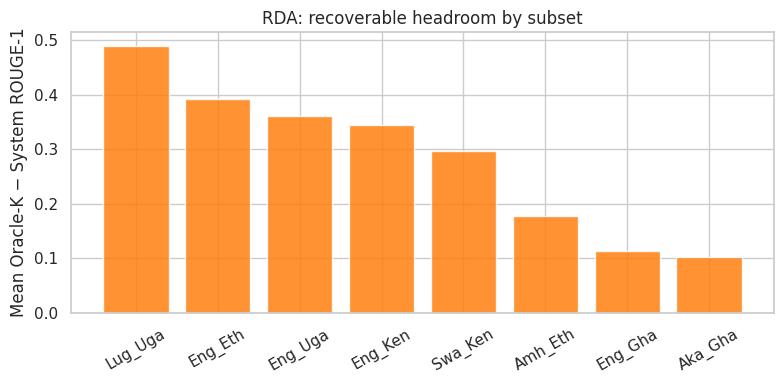


Sample low-ROUGE rows (bottom 3 per weak subset):


,subset,system_r1,oracle_k,fuzz_sim,question,gold,pred
0,Amh_Eth,0.000,0.182,55.4,ለእናቴ የ አባላዘር በሽታ ሊይዘኝ እንደሚችል መንገር እፈራለሁ። ሌላ ማንን ማነጋገር እችላለሁ?…,ከማህበረሰብ የጤና ሰራተኛ፣ ከክሊኒክ ነርስ ወይም ከታመነች እህት ወይም ሴት ዘመድ ጋር ይነጋገሩ። የጤና መረጃዎን በሚስጥር መ…,በዓለም አቀፍ ደረጃ በጣም የተለመደው አባላዘር በሽታ ኤችፒቪ ሲሆን አብዛኛዎቹ የግብረ ሥጋ ግንኙነት ፈጻሚ ሰዎች በተወሰነ ጊ…
1,Amh_Eth,0.000,0.158,49.5,እርግዝናን ለመከላከል መድሀኒት (ኪኒን/መረፌ) መጠቀም ኃጢአት ነው?…,ብዙ የሃይማኖት መሪዎች የቤተሰብ ምጣኔ መጠቀም ኃጢአት እንዳልሆነ ይገልጻሉ። ይህ የእናትን ጤና እና ያሉትን ልጆች ደህንነት ለ…,በመጨረሻው የእርግዝና ወር ውስጥ የሚሰጥ የፀረ-ቫይረስ ማፈን ሕክምና (እንደ አሲክሎቪር ያሉ)።…
2,Amh_Eth,0.000,0.372,56.2,ኤች አይቪ በደማቸው የሚገኝ ሰዎች ረጅም እድሜ ለመኖር ምን ማድረግ አለባቸው?…,የኤች አይ ቪ መድሃኒትን በአግባቡ በመውሰድ ኤች አይቪ በደማቸው የሚገኝ ሰዎች ጤነኛ ህይወት መምራት ይችላሉ:: እነዚህ መድሃኒ…,አዎ። በየቀኑ በሚወሰድ መድኃኒት ፣ ኤችአይቪ ያለበት ሰው መደበኛ የህይወት ጣሪያ ሊኖረውና ደስተኛና ሙሉ ሕይወት ሊኖር ይችላል…
3,Aka_Gha,0.000,0.013,56.7,Nneɛma bɛn na ɛbɛboa me ma mayɛ mmabun anaa nnamfofoɔ mmoa kuo (peer support group)?…,Akwankyerɛ nkrataa (Tip sheets). Nteteeɛ (Orientations).…,Nneɛma ahorow ne mmoa nkitahodi ahorow wɔ hɔ a ɛbɛboa wo ma wo ne atipɛnfo akuw …
4,Aka_Gha,0.000,0.211,55.1,"Mɛyɛ dɛn ama akyerɛkyerɛ hyeɛ hyehyɛ ama nnamfo, hokafoɔ ne afoforo aa wɔnni m'abusua mu senea wɔ b…",Hyehyɛ ahyeɛ ɛbu wokokoam/w'ahodeso. Kyerɛ deɛ wopɛ ne deɛ wompɛ. Kasa pintinn.…,Fa nhwɛso di anim: Fa adwene mu nhumu ka wo daadaa dwumadi ho na ka wo suahu aho…
5,Aka_Gha,0.000,0.071,58.6,SRH nsɛm bɛn na mmabun betumi de akɔ 'online crisis' akɔpɛ ho mmoa?…,"Awoɔ ntoatoasoɔ, STI, Nyinsɛn, Abusuabɔ, Basabasayɛ, Nyin.…",Mmabun betumi de nsɛm ama anaasɛ wɔde wɔn suahu akyerɛ wɔ intanɛt so ɔhaw ahorow…
6,Eng_Gha,0.000,1.000,56.2,"How can my race, ethnicity, socioeconomic background, or religion intersect with my SOGI and influen…",your school nurse or healthcare worker will discuss issues of sexuality with you…,"Imagine identities like race, ethnicity, socioeconomic background, and sexual or…"
7,Eng_Gha,0.017,0.151,53.6,"How can I report GBV confidentially, especially if I'm not sure if I want to press charges? (anonymo…",The domestic violence unit of the Ghana Police Service addresses issues of GBV p…,"Options: Abortion: If you're not ready to parent, abortion is a legal option in …"
8,Eng_Gha,0.018,1.000,69.8,What are some resources available for learning more about pronouns and gender identity?…,"In Ghana, the constituition oInly recognises binary gender with she/he pronouns …","As an adolescent, you can access education on reproductive health through variou…"


Logged experiment E14: RDA oracle ceiling (train-only)

RDA complete — figures saved to /content/multilingual-health-qa/figures


In [29]:
print(f'RDA — Retrieval Diagnostic Analysis on {len(val):,} val rows (train-only index, n={len(train):,})...')
if not compute_rouge:
    print('ROUGE utilities not loaded — run Section 8 first.')
else:
    if 'WhitespaceTokenizer' not in globals():
        raise RuntimeError('Run Section 8 (cell-eval) first — WhitespaceTokenizer is not defined.')
    from rouge_score import rouge_scorer as _rouge_scorer_mod
    _rda_scorer = _rouge_scorer_mod.RougeScorer(
        ['rouge1'],
        tokenizer=WhitespaceTokenizer(),
        use_stemmer=False,
    )
    def _rouge1_pair(prediction, reference):
        return float(_rda_scorer.score(str(reference), str(prediction))['rouge1'].fmeasure)
    print('Building train-only diagnostic index...')
    rda_index = AdvancedRetrievalAnswerer(
        question_col=QUESTION_COL,
        answer_col=ANSWER_COL,
        id_col='ID',
        group_col=LANG_COL,
        ngram_range=NGRAM_RANGE,
        max_features=MAX_FEATURES,
        top_k=RDA_TOP_K,
        rerank_top_n=RERANK_TOP_N,
        sparse_weight=SPARSE_WEIGHT,
        bm25_weight=BM25_WEIGHT,
        use_dense=False,
        use_bm25=USE_BM25,
        use_cross_encoder=False,
        fuzzy_threshold=FUZZY_MATCH_THRESHOLD,
        min_answer_length=MIN_ANSWER_LENGTH,
        min_answer_length_by_group=SUBSET_MIN_ANSWER_LENGTH,
        answer_rerank_weight=0.0,
    ).fit(train)

    # conflicting-answer map on cleaned train
    _train_q = train[QUESTION_COL].map(normalize_question)
    _conflict_n = (
        train.assign(_q=_train_q)
        .groupby('_q')[ANSWER_COL]
        .nunique()
        .to_dict()
    )

    # pre-index train questions per subset for fuzzy@1
    _subset_norms = {}
    for subset, sub in train.groupby(LANG_COL):
        _subset_norms[subset] = sub[QUESTION_COL].map(normalize_question).tolist()

    system_preds = None
    if 'val_pred_hybrid' in dir() and len(val_pred_hybrid) == len(val):
        system_preds = val_pred_hybrid
        print('Comparing against hybrid retrieval predictions.')
    else:
        print('val_pred_hybrid not found — Oracle metrics only (re-run E08 cell for System column).')

    rda_rows = []
    for _, row in tqdm(val.iterrows(), total=len(val), desc='RDA'):
        q = clean_text(row[QUESTION_COL])
        gold = row[ANSWER_COL]
        subset = row[LANG_COL]
        qn = normalize_question(q)

        norms = _subset_norms.get(subset, [])
        fuzz_match = process.extractOne(qn, norms, scorer=fuzz.ratio) if norms else None
        fuzz_sim = float(fuzz_match[1]) if fuzz_match else 0.0

        indices, _, model = rda_index.get_neighbors(q, group=subset, exclude_id=None)
        if not indices:
            oracle_1 = oracle_k = 0.0
        else:
            ans_1 = model['answers'][indices[0]]
            oracle_1 = _rouge1_pair(ans_1, gold)
            oracle_k = max(_rouge1_pair(model['answers'][i], gold) for i in indices)

        nearest_train_q = str(model['questions'][indices[0]]) if indices else ''
        n_answers_for_q = int(_conflict_n.get(normalize_question(nearest_train_q), 1)) if indices else 1

        sys_r1 = None
        if system_preds is not None:
            sys_r1 = _rouge1_pair(system_preds[len(rda_rows)], gold)

        rda_rows.append({
            'subset': subset,
            'fuzz_sim': fuzz_sim,
            'oracle_1': oracle_1,
            'oracle_k': oracle_k,
            'system_r1': sys_r1,
            'headroom': (oracle_k - sys_r1) if sys_r1 is not None else None,
            'conflicting_nearest_q': n_answers_for_q > 1,
            'gold_len': len(str(gold)),
        })

    rda = pd.DataFrame(rda_rows)

    overall = pd.Series({
        'n': len(rda),
        'fuzz_sim_mean': rda['fuzz_sim'].mean(),
        'oracle_1_mean': rda['oracle_1'].mean(),
        'oracle_k_mean': rda['oracle_k'].mean(),
        'conflict_rate': rda['conflicting_nearest_q'].mean(),
    })
    if rda['system_r1'].notna().any():
        overall['system_r1_mean'] = rda['system_r1'].mean()
        overall['headroom_mean'] = rda['headroom'].mean()

    print('\nRDA summary (overall):')
    display(overall.round(4).to_frame('value'))

    print('\nRDA summary by subset:')
    rda_by_subset = rda.groupby('subset').agg(
        n=('oracle_1', 'size'),
        fuzz_sim_mean=('fuzz_sim', 'mean'),
        oracle_1_mean=('oracle_1', 'mean'),
        oracle_k_mean=('oracle_k', 'mean'),
        conflict_rate=('conflicting_nearest_q', 'mean'),
        **(
            {'system_r1_mean': ('system_r1', 'mean'), 'headroom_mean': ('headroom', 'mean')}
            if rda['system_r1'].notna().any() else {}
        ),
    ).round(4)
    display(rda_by_subset)

    # --- Chart 1: fuzzy similarity histogram ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(rda['fuzz_sim'], bins=30, color='#1f77b4', alpha=0.85, edgecolor='white')
    ax.axvline(FUZZY_MATCH_THRESHOLD, color='red', linestyle='--', label=f'fuzzy threshold={FUZZY_MATCH_THRESHOLD}')
    ax.set_xlabel('Best fuzzy similarity (val Q → train Q, same subset)')
    ax.set_ylabel('Val questions')
    ax.set_title('RDA: train→val question similarity (cleaned train corpus)')
    ax.legend()
    plt.tight_layout()
    save_fig('rda_similarity_hist.png')
    plt.show()

    # --- Chart 2: oracle vs system by subset ---
    plot_cols = ['oracle_1_mean', 'oracle_k_mean']
    if 'system_r1_mean' in rda_by_subset.columns:
        plot_cols.append('system_r1_mean')
    plot_df = rda_by_subset[plot_cols].sort_values('oracle_k_mean')
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(plot_df))
    w = 0.25
    for i, col in enumerate(plot_cols):
        label = col.replace('_mean', '').replace('_', ' ')
        ax.bar(x + (i - len(plot_cols) / 2 + 0.5) * w, plot_df[col], width=w, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=30, ha='right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Mean ROUGE-1 F1')
    ax.set_title('RDA: Oracle ceilings vs system (per subset)')
    ax.legend()
    plt.tight_layout()
    save_fig('rda_oracle_vs_system.png')
    plt.show()

    # --- Chart 3: headroom ---
    if 'headroom_mean' in rda_by_subset.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        headroom = rda_by_subset['headroom_mean'].sort_values(ascending=False)
        ax.bar(headroom.index, headroom.values, color='#ff7f0e', alpha=0.85)
        ax.set_ylabel('Mean Oracle-K − System ROUGE-1')
        ax.set_title('RDA: recoverable headroom by subset')
        ax.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        save_fig('rda_headroom_by_subset.png')
        plt.show()

    # --- failure samples for weak subsets ---
    weak_subsets = ['Amh_Eth', 'Aka_Gha', 'Eng_Gha']
    if system_preds is not None:
        rda['_gold'] = val[ANSWER_COL].values
        rda['_pred'] = system_preds
        rda['_question'] = val[QUESTION_COL].values
        print(f'\nSample low-ROUGE rows (bottom {RDA_SAMPLE_FAILURES} per weak subset):')
        samples = []
        for subset in weak_subsets:
            sub = rda[rda['subset'] == subset].sort_values('system_r1').head(RDA_SAMPLE_FAILURES)
            for _, r in sub.iterrows():
                samples.append({
                    'subset': subset,
                    'system_r1': round(r['system_r1'], 3),
                    'oracle_k': round(r['oracle_k'], 3),
                    'fuzz_sim': round(r['fuzz_sim'], 1),
                    'question': str(r['_question'])[:100] + '…',
                    'gold': str(r['_gold'])[:80] + '…',
                    'pred': str(r['_pred'])[:80] + '…',
                })
        if samples:
            display(pd.DataFrame(samples))

    tracker.log(
        experiment_id='E14',
        name='RDA oracle ceiling (train-only)',
        category='diagnostic',
        change=f'Oracle-K on cleaned train, k={RDA_TOP_K}',
        rationale='Quantify retrieval headroom after Q+A dedup; diagnose subset failures',
        rouge1=float(rda['system_r1'].mean()) if rda['system_r1'].notna().any() else None,
        rougel=None,
        notes=(
            f"oracle_1_mean={rda['oracle_1'].mean():.4f}, "
            f"oracle_k_mean={rda['oracle_k'].mean():.4f}"
        ),
    )
    print('\nRDA complete — figures saved to', FIGURES_DIR)


## 14 — Export predictions

### Output format

Each exported row contains the example `ID` (from `Test.csv`) and the same predicted answer in three target columns (`TargetRLF1`, `TargetR1F1`, `TargetLLM`).

### Function

`make_submission(ids, predictions, output_path)` cleans model output (removes T5 sentinel tokens), validates row count and column equality, and writes a UTF-8 CSV.

Run the cells below after completing baselines (Sections 10–11) and hybrid retrieval (Section 13).


In [30]:
FALLBACK_ANSWER = 'Please consult a healthcare professional for personalised advice.'


def make_submission(ids, predictions, output_path):
    if len(predictions) != len(test):
        raise ValueError(
            f'Prediction count mismatch: got {len(predictions)}, expected {len(test)}. '
            'Re-run test inference before creating the submission.'
        )

    pred_map = {}
    for row_id, pred in zip(ids, predictions):
        text = re.sub(r'<extra_id_\d+>', '', str(pred)).strip()
        if not text or text.lower() == 'nan':
            text = FALLBACK_ANSWER
        pred_map[row_id] = text

    sub = test[[TEST_ID_COL]].copy().rename(columns={TEST_ID_COL: 'ID'})
    answers = sub['ID'].map(pred_map)
    missing_mask = answers.isna() | (answers.astype(str).str.strip() == '')
    if missing_mask.any():
        missing_ids = sub.loc[missing_mask, 'ID'].tolist()
        print(f'WARNING: {missing_mask.sum()} IDs without predictions — filling with fallback')
        print(f'  IDs: {missing_ids[:10]}')
        answers = answers.fillna(FALLBACK_ANSWER)
        answers.loc[missing_mask] = FALLBACK_ANSWER

    sub['TargetRLF1'] = answers
    sub['TargetR1F1'] = answers
    sub['TargetLLM'] = answers

    assert len(sub) == len(test), f'Row mismatch: {len(sub)} vs {len(test)}'
    assert set(pred_map) == set(test[TEST_ID_COL]), 'Prediction IDs do not match Test.csv'
    assert (sub['TargetRLF1'] == sub['TargetR1F1']).all()
    assert (sub['TargetRLF1'] == sub['TargetLLM']).all()
    assert sub[['TargetRLF1', 'TargetR1F1', 'TargetLLM']].notna().all().all()
    assert (sub['TargetRLF1'].astype(str).str.strip() != '').all(), 'Empty target columns remain'

    sub.to_csv(output_path, index=False, encoding='utf-8')
    print(f'Saved {output_path} ({sub.shape})')
    display(sub.head(3))
    return sub


In [31]:
sub_tfidf = make_submission(test[TEST_ID_COL].values, test_pred_tfidf, OUTPUT_TFIDF)
sub_llm   = make_submission(test[TEST_ID_COL].values, test_pred_llm, OUTPUT_LLM)


Saved /content/multilingual-health-qa/submission_tfidf_baseline.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n...","Nhomasua Nneɛma: Hwehwɛ nhoma, nkratawa, anaa intanɛt so nneɛma a efi nnwumakuo ahorow a wogye wɔn di mu a ɛfa GBV n..."
1,ID_TS_Aka_Gha_1C80317F,"Yiw, mmabun betumi ahwehwɛ mmara kwan so mmoa sɛ wogye di sɛ wɔabu hokwan a wɔwɔ sɛ wodi wɔn ho so wɔ nipadua mu no ...","Yiw, mmabun betumi ahwehwɛ mmara kwan so mmoa sɛ wogye di sɛ wɔabu hokwan a wɔwɔ sɛ wodi wɔn ho so wɔ nipadua mu no ...","Yiw, mmabun betumi ahwehwɛ mmara kwan so mmoa sɛ wogye di sɛ wɔabu hokwan a wɔwɔ sɛ wodi wɔn ho so wɔ nipadua mu no ..."
2,ID_TS_Aka_Gha_06671AD1,Nnipa a wɔn ho nka ho tee yɛ biribi. Ɛsi basabasayɛ kwan denam mmoa a wɔde ma (bystanders) ma wohu/yɛ biribi no so. ...,Nnipa a wɔn ho nka ho tee yɛ biribi. Ɛsi basabasayɛ kwan denam mmoa a wɔde ma (bystanders) ma wohu/yɛ biribi no so. ...,Nnipa a wɔn ho nka ho tee yɛ biribi. Ɛsi basabasayɛ kwan denam mmoa a wɔde ma (bystanders) ma wohu/yɛ biribi no so. ...


Saved /content/multilingual-health-qa/submission_llm_baseline.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,nneɛma,nneɛma,nneɛma
1,ID_TS_Aka_Gha_1C80317F,?eловна,?eловна,?eловна
2,ID_TS_Aka_Gha_06671AD1,.,.,.


### Export — hybrid retrieval predictions

Generate test-set predictions with the E08 configuration. Test export uses a slightly lower fuzzy threshold to capture more near-duplicate questions.


In [32]:
_saved_fuzzy = hybrid_answerer.fuzzy_threshold
hybrid_answerer.fuzzy_threshold = FUZZY_MATCH_THRESHOLD_TEST
print(f'Generating hybrid retrieval predictions for {len(test):,} test questions '
      f'(fuzzy>={FUZZY_MATCH_THRESHOLD_TEST})...')
test_pred_hybrid, test_sim_hybrid, test_match_hybrid = hybrid_answerer.predict(
    test,
    question_col=TEST_QUESTION_COL,
    group_col=TEST_LANG_COL,
    log_every=RETRIEVAL_LOG_EVERY,
    desc='Test retrieval',
    references=None,
)

print(f'  Mean score      : {np.mean(test_sim_hybrid):.4f}')
print(f'  Median ans len  : {np.median([len(str(a)) for a in test_pred_hybrid]):.0f} chars')
print(f'  Answers < {MIN_ANSWER_LENGTH} chars: '
      f'{sum(1 for p in test_pred_hybrid if len(str(p)) < MIN_ANSWER_LENGTH)}')

hybrid_answerer.fuzzy_threshold = _saved_fuzzy
sub_hybrid = make_submission(test[TEST_ID_COL].values, test_pred_hybrid, OUTPUT_RETRIEVAL)
print(f'Exported: {OUTPUT_RETRIEVAL}')


Generating hybrid retrieval predictions for 2,618 test questions (fuzzy>=88)...


Test retrieval:   0%|          | 0/2618 [00:00<?, ?it/s]

\nMatch breakdown (2,618 rows): {'retrieval': 2093, 'fuzzy': 522, 'retrieval_short': 3}
  Mean score      : 2.5871
  Median ans len  : 520 chars
  Answers < 200 chars: 154
Saved /content/multilingual-health-qa/submission_hybrid_retrieval.csv ((2618, 4))


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,Nneɛma bi a wɔde bɛyɛ intanɛt so nkyerɛkyerɛ anaa ɔyɛkyerɛ a ɛfa nnuru a wɔde siw nyinsɛn ano a wɔde di dwuma yiye h...,Nneɛma bi a wɔde bɛyɛ intanɛt so nkyerɛkyerɛ anaa ɔyɛkyerɛ a ɛfa nnuru a wɔde siw nyinsɛn ano a wɔde di dwuma yiye h...,Nneɛma bi a wɔde bɛyɛ intanɛt so nkyerɛkyerɛ anaa ɔyɛkyerɛ a ɛfa nnuru a wɔde siw nyinsɛn ano a wɔde di dwuma yiye h...
1,ID_TS_Aka_Gha_1C80317F,"Ahintasɛm a wobu so betumi de ɔhaw kɛse aba mmabun so, a nea ɛka ho ne: Ahotoso a wɔsɛe no: Ahintasɛm a wobu so betu...","Ahintasɛm a wobu so betumi de ɔhaw kɛse aba mmabun so, a nea ɛka ho ne: Ahotoso a wɔsɛe no: Ahintasɛm a wobu so betu...","Ahintasɛm a wobu so betumi de ɔhaw kɛse aba mmabun so, a nea ɛka ho ne: Ahotoso a wɔsɛe no: Ahintasɛm a wobu so betu..."
2,ID_TS_Aka_Gha_06671AD1,"Mmabun betumi asusuw ahotoso ne ahotoso a ɛwɔ nsɛm ho amanneɛbɔ mu denam nneɛma te sɛ ɔkyerɛwfo no nimdeɛ, abasobɔde...","Mmabun betumi asusuw ahotoso ne ahotoso a ɛwɔ nsɛm ho amanneɛbɔ mu denam nneɛma te sɛ ɔkyerɛwfo no nimdeɛ, abasobɔde...","Mmabun betumi asusuw ahotoso ne ahotoso a ɛwɔ nsɛm ho amanneɛbɔ mu denam nneɛma te sɛ ɔkyerɛwfo no nimdeɛ, abasobɔde..."


Exported: /content/multilingual-health-qa/submission_hybrid_retrieval.csv


## 15 — Experiment summary and discussion

### Experiment table

Run the code cell below after completing all experiments. Export `experiment_log.json` and the summary table for your written report.

### Figures

| File | Description |
|---|---|
| `experiment_progression.png` | ROUGE-1 F1 by experiment (horizontal bar) |
| `experiment_progression_bars.png` | ROUGE-1 and ROUGE-L by experiment ID |
| `experiment_progression_line.png` | ROUGE progression across experiments |
| `retrieval_similarity_hist.png` | Match score distribution on validation |
| `retrieval_rouge_by_subset.png` | Per-subset ROUGE for hybrid retrieval |
| `retrieval_k_ablation.png` | Top-k sensitivity |
| `rda_similarity_hist.png` | Train→val fuzzy similarity |
| `rda_oracle_vs_system.png` | Oracle-1/K vs system ROUGE by subset |
| `rda_headroom_by_subset.png` | Recoverable ROUGE gap (Oracle-K − System) |

### Discussion prompts

1. Why did hybrid retrieval outperform zero-shot LLM? Consider overlap, answer length, and in-domain vocabulary.
2. Which subsets improved least? Relate to training counts and script (Ge'ez vs Latin).
3. What is the trade-off between indexing `Val.csv` and honest local evaluation (E09)?
4. What does RDA show about Oracle-K vs system ROUGE? Which subsets have the largest headroom?
5. How did exact Q+A dedup and subset min-length rules affect low-resource subsets?


Experiment log:


,id,name,category,change,rouge1_f1,rougeL_f1,notes
0,E01,TF-IDF global retrieval,baseline,"Char n-gram TF-IDF, single global index",0.427465,0.373818,
1,E02,TF-IDF per-subset retrieval,baseline,Char n-gram TF-IDF with per-subset indexes,0.419985,0.364729,
2,E07,Zero-shot google/mt5-small (E07),baseline,"Model=google/mt5-small, language_prompt=True, beams=4",0.015284,0.014362,
3,E08,Hybrid retrieval (final),retrieval,"k=50, CE=0.5, aq=0.45, abm=0.3",0.399260,0.340624,"match_stats={'retrieval': 6540, 'retrieval_short': 78, 'exact': 68}"
5,E09,Advanced retrieval (train-only index),retrieval,Index Train.csv only,0.376664,0.317820,
4,E11,Top-k ablation,analysis,"Compared k in [5, 10, 15, 20]; production k=50",0.395366,0.336650,"[{""top_k"":5,""rouge1_f1"":0.3954,""rougeL_f1"":0.3367},{""top_k"":10,""rouge1_f1"":0.3812,""rougeL_f1"":0.3224},{""top_k"":15,""r..."
6,E14,RDA oracle ceiling (train-only),diagnostic,"Oracle-K on cleaned train, k=50",0.399260,NaN,"oracle_1_mean=0.4063, oracle_k_mean=0.6768"


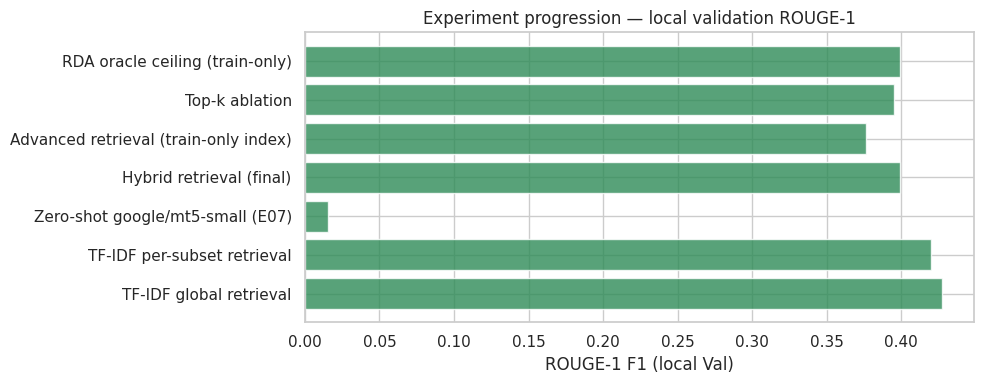

Saved: /content/multilingual-health-qa/figures/experiment_progression.png


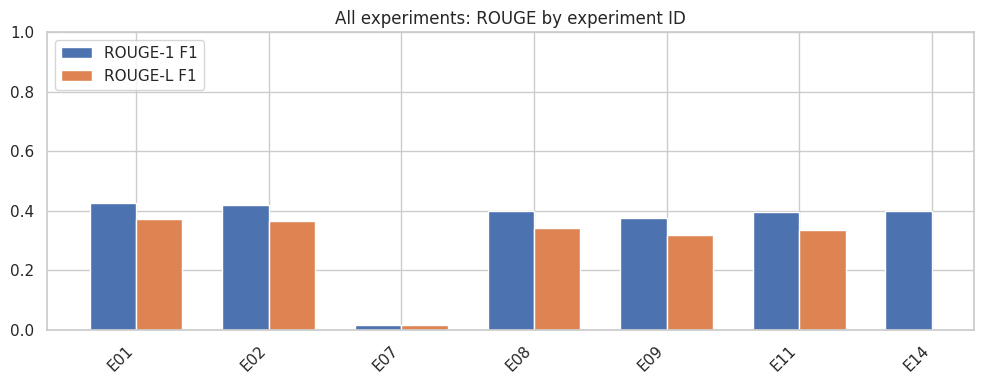

Saved: /content/multilingual-health-qa/figures/experiment_progression_bars.png


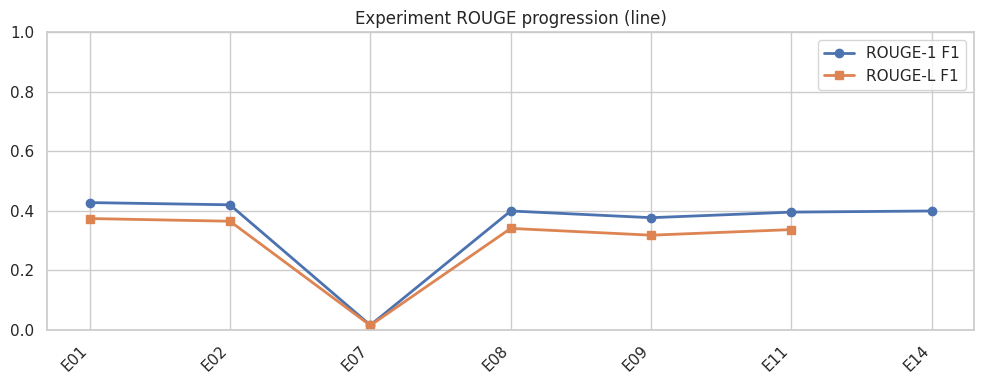

Saved: /content/multilingual-health-qa/figures/experiment_progression_line.png

Figures saved under: /content/multilingual-health-qa/figures
Experiment log: /content/multilingual-health-qa/experiment_log.json


In [33]:
summary = tracker.to_dataframe()
print('Experiment log:')
display(summary)

if not summary.empty and summary['rouge1_f1'].notna().any():
    plot_df = summary.dropna(subset=['rouge1_f1'])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(plot_df['name'], plot_df['rouge1_f1'], color='seagreen', alpha=0.8)
    ax.set_xlabel('ROUGE-1 F1 (local Val)')
    ax.set_title('Experiment progression — local validation ROUGE-1')
    exp_path = FIGURES_DIR / 'experiment_progression.png'
    plt.tight_layout()
    plt.savefig(exp_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {exp_path}')

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w/2, plot_df['rouge1_f1'], w, label='ROUGE-1 F1')
    if plot_df['rougeL_f1'].notna().any():
        ax.bar(x + w/2, plot_df['rougeL_f1'], w, label='ROUGE-L F1')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['id'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title('All experiments: ROUGE by experiment ID')
    ax.legend()
    plt.tight_layout()
    exp_bar_path = FIGURES_DIR / 'experiment_progression_bars.png'
    plt.savefig(exp_bar_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {exp_bar_path}')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(len(plot_df)), plot_df['rouge1_f1'], marker='o', label='ROUGE-1 F1', linewidth=2)
    if plot_df['rougeL_f1'].notna().any():
        ax.plot(range(len(plot_df)), plot_df['rougeL_f1'], marker='s', label='ROUGE-L F1', linewidth=2)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df['id'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title('Experiment ROUGE progression (line)')
    ax.legend()
    plt.tight_layout()
    exp_line_path = FIGURES_DIR / 'experiment_progression_line.png'
    plt.savefig(exp_line_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {exp_line_path}')

print(f'\nFigures saved under: {FIGURES_DIR}')
print(f'Experiment log: {EXPERIMENT_LOG_PATH}')


## 16 — Reproducibility notes

| Item | Value |
|---|---|
| Random seed | `SEED` (set in imports cell) |
| Validation metric | ROUGE-1 / ROUGE-L F1 via `rouge-score` |
| Tokenizer | Whitespace (language-agnostic) |
| Experiment log | `WORK_DIR/experiment_log.json` |
| Figures | `WORK_DIR/figures/` |

Re-run Sections 2–8 before retrieval or LLM experiments after a runtime restart. Document the Colab runtime type and package versions when reporting results.
